
Running Sevcik FD in FAST mode
decimate=2, max_samples=60000
Loaded EEG segment: 106944 samples x 32 channels
Segment: [814.571, 921.515] sec
After FAST mode preprocessing:
  Segment shape: 53472 samples x 32 channels
  Effective sampling rate: 500.00 Hz
  Effective duration: 106.94 sec

Sevcik Fractal Dimensions:
   channel  sevcik_fd  n_samples  normalized_curve_length  amplitude_range  \
0       Pz   1.745849      53472              5636.152366         7.254427   
1      CP5   1.744730      53472              5563.606219         8.396437   
2      FC5   1.742769      53472              5438.680442         8.132710   
3       P4   1.742502      53472              5421.934323         6.765780   
4       Cz   1.738543      53472              5178.960555         6.707788   
5      FC2   1.736599      53472              5063.669773         7.883181   
6       P3   1.735894      53472              5022.486502         6.214986   
7       C3   1.734013      53472              4914.271827  

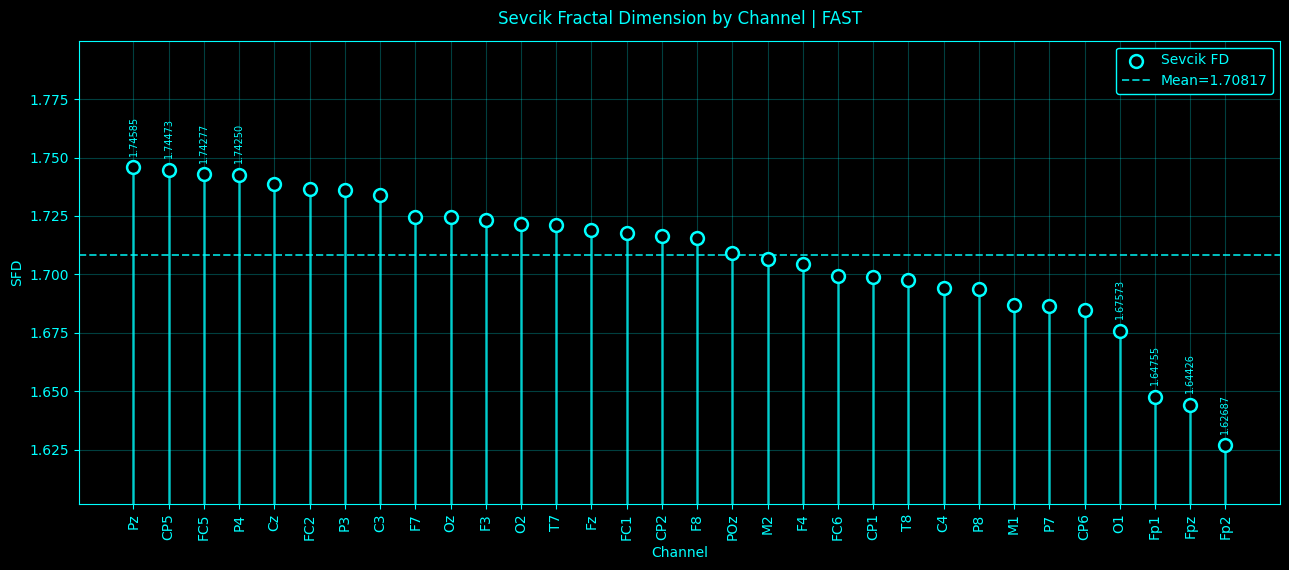

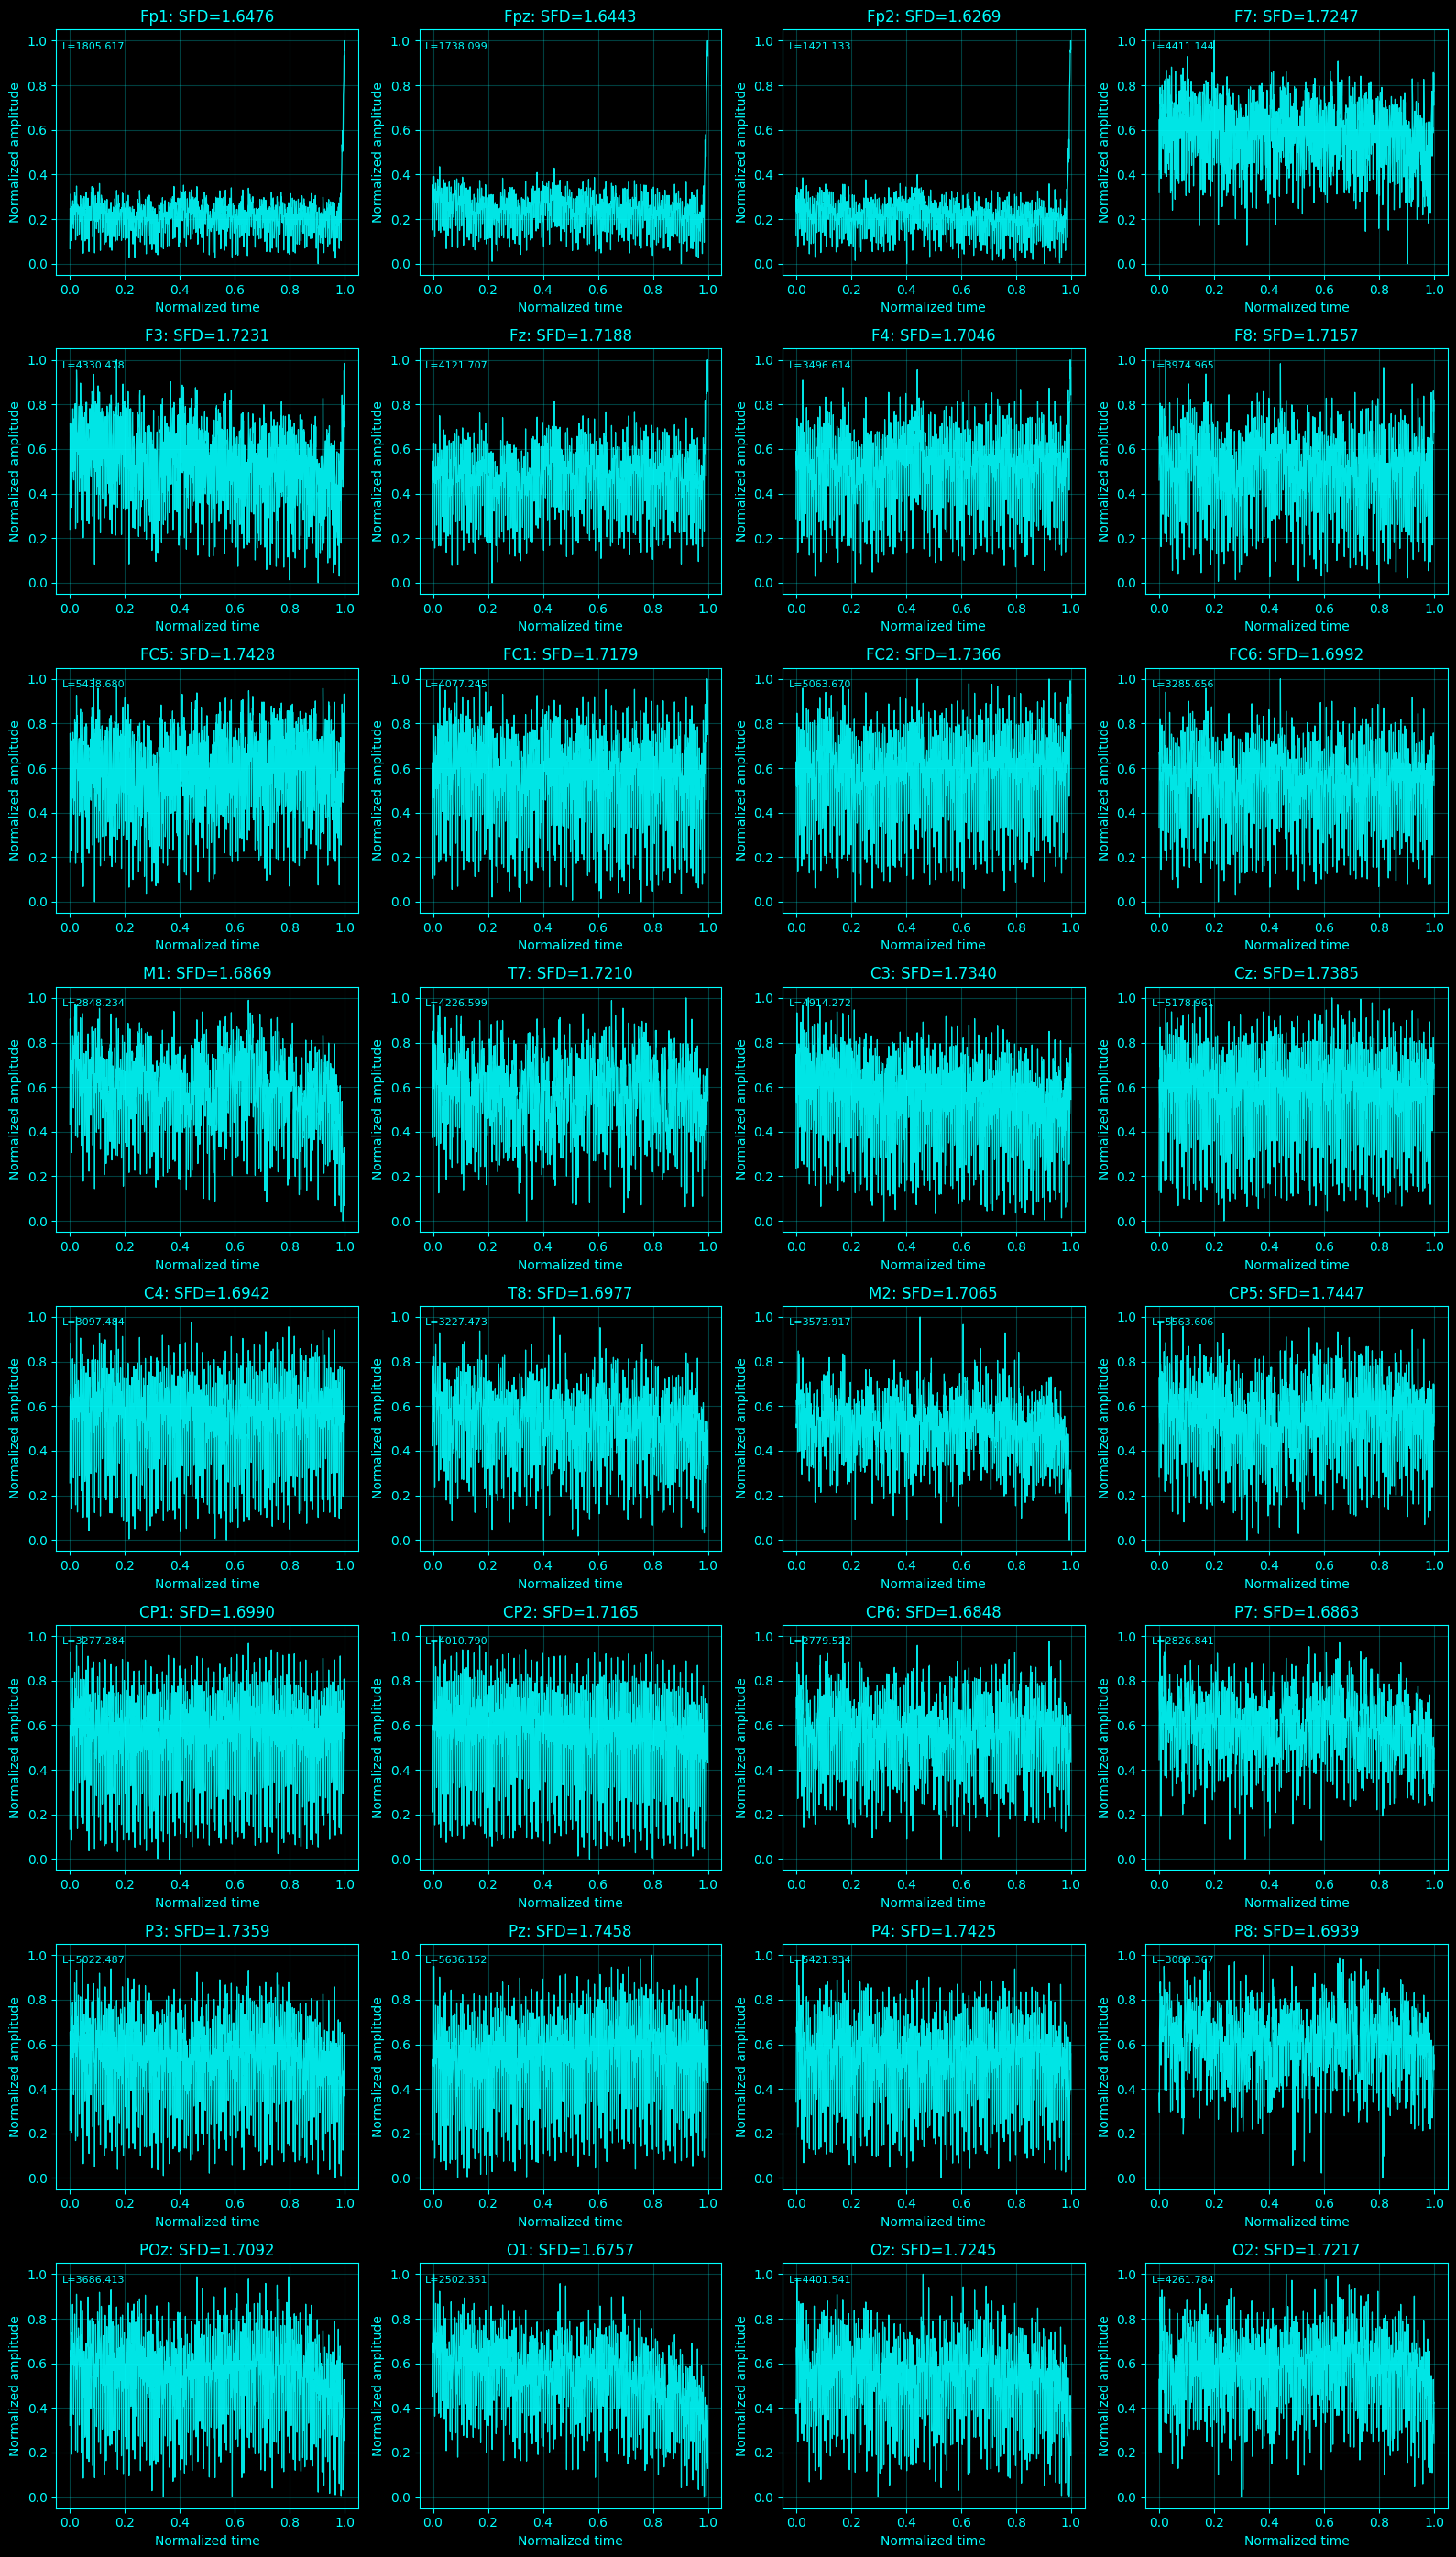

All-channel Sevcik diagnostic plot saved to: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_sevcik/all_channels_sevcik_normalized_curve_diagnostics.png


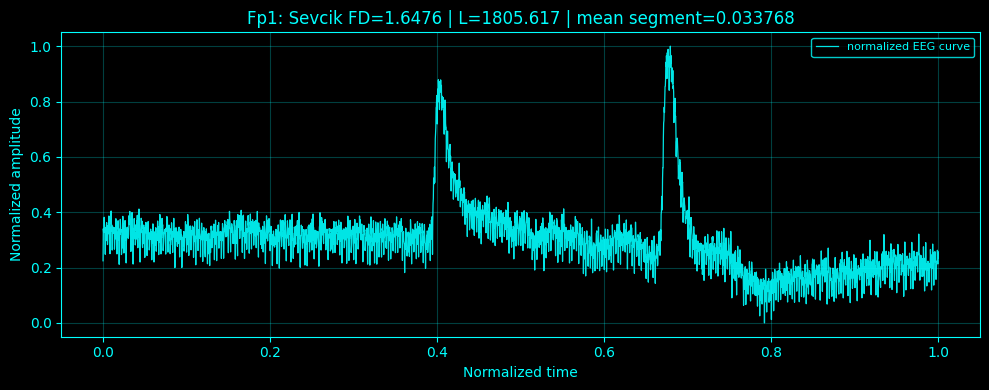

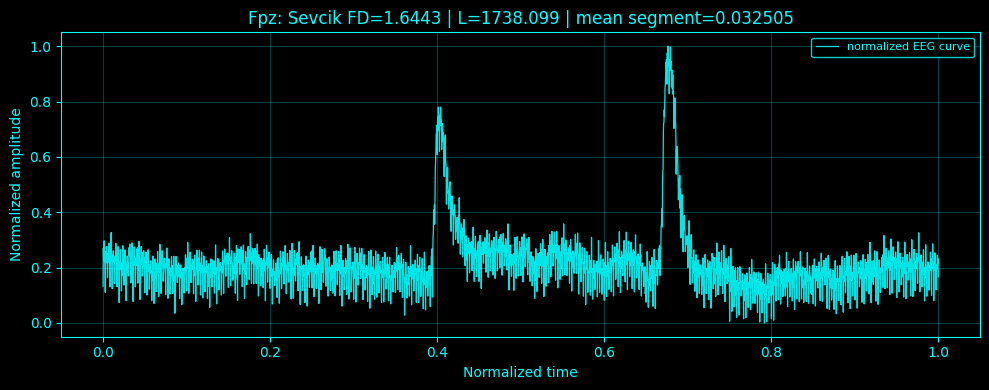

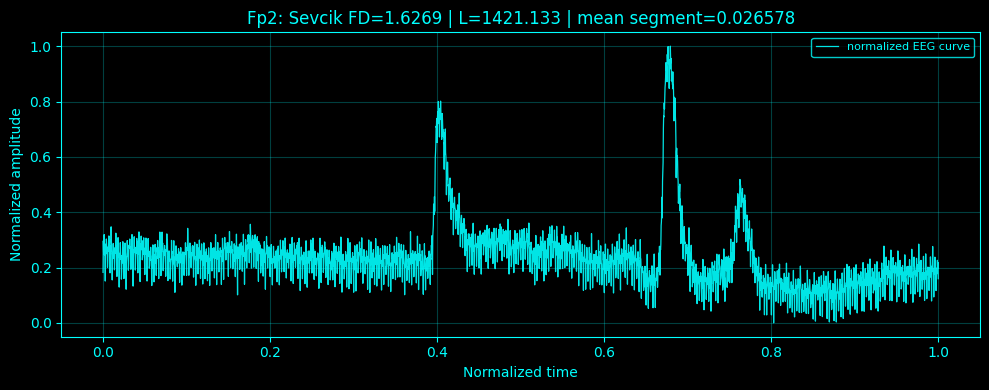

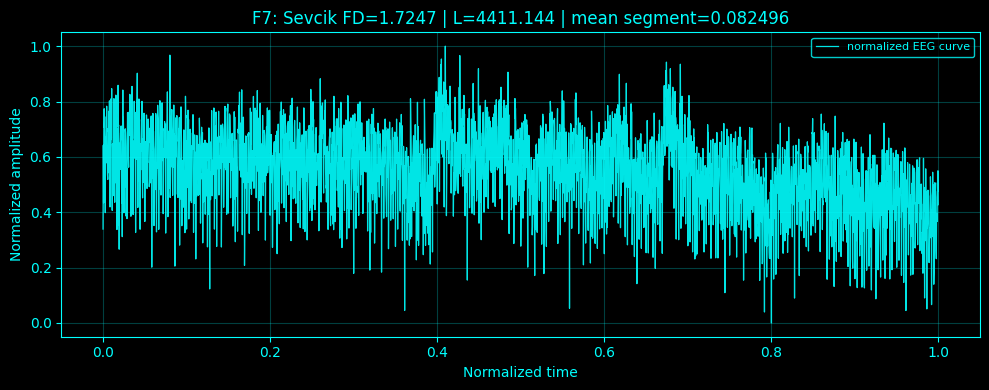

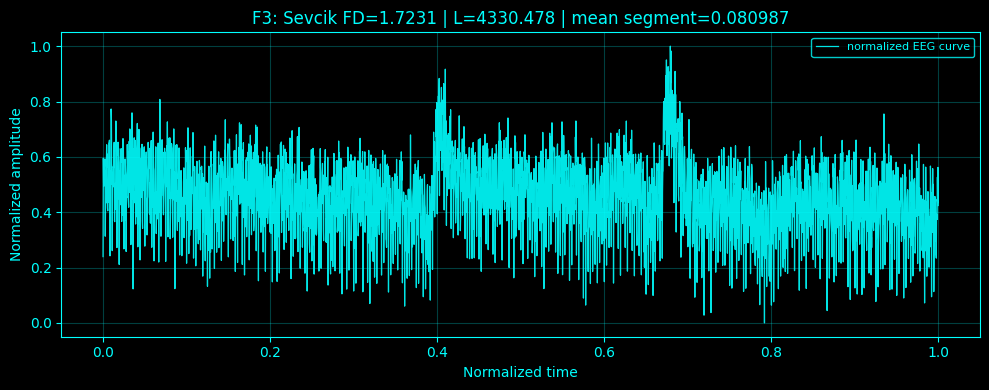

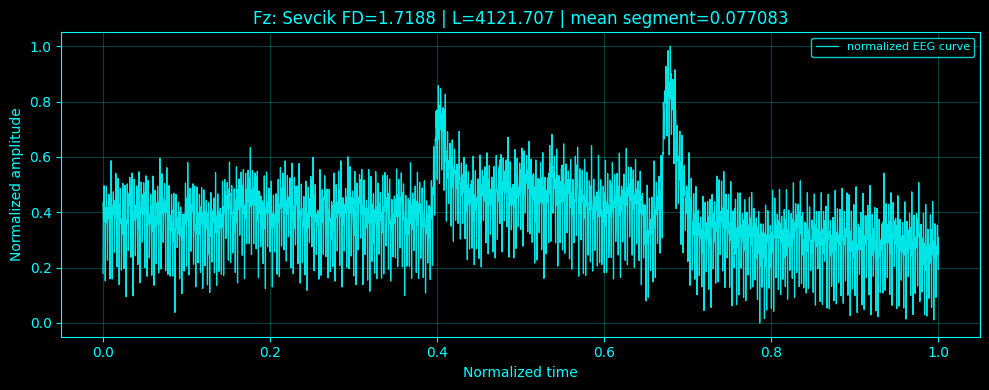

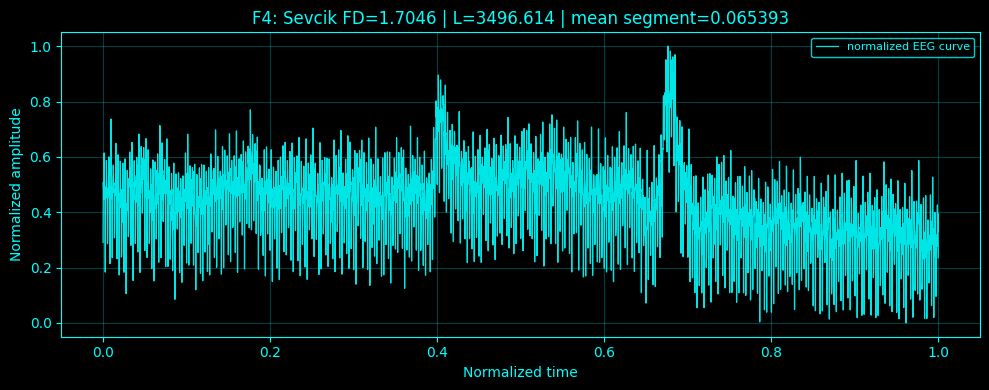

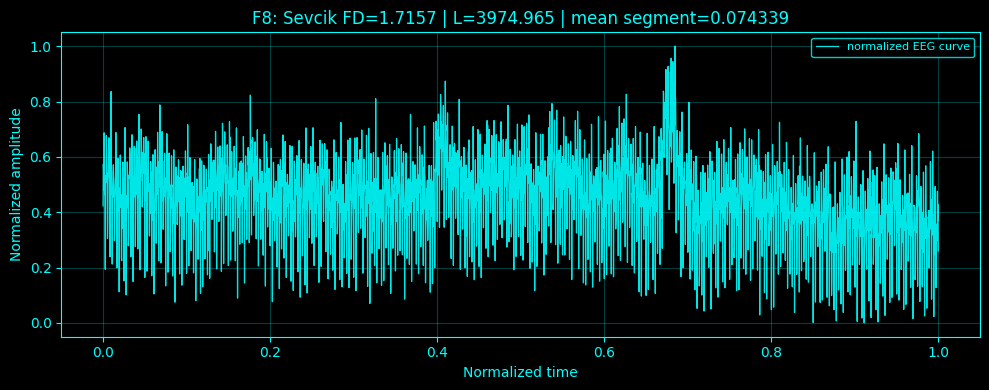

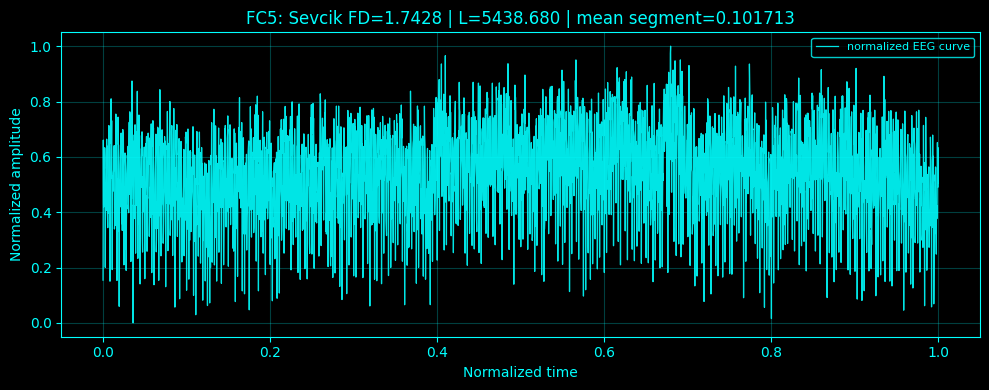

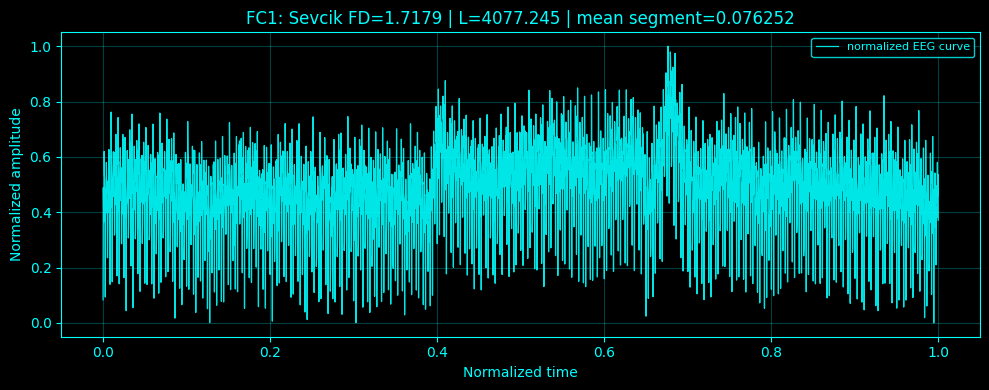

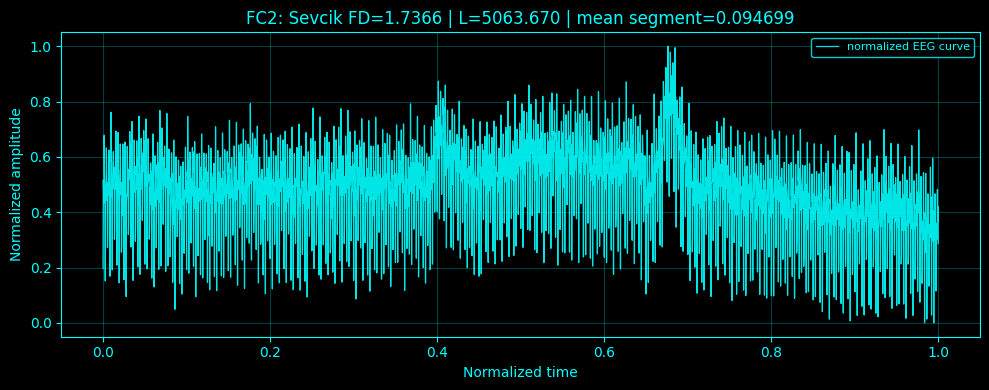

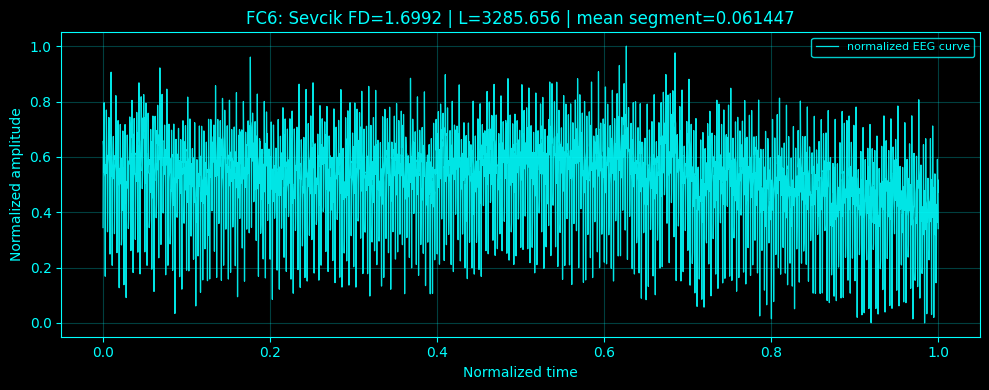

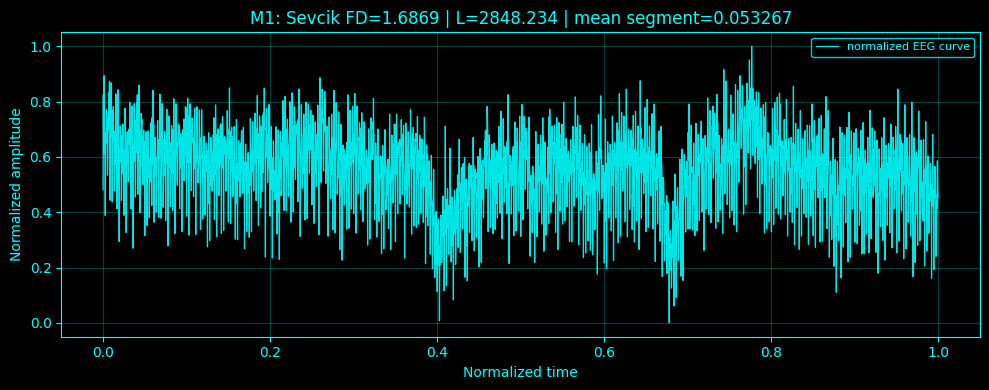

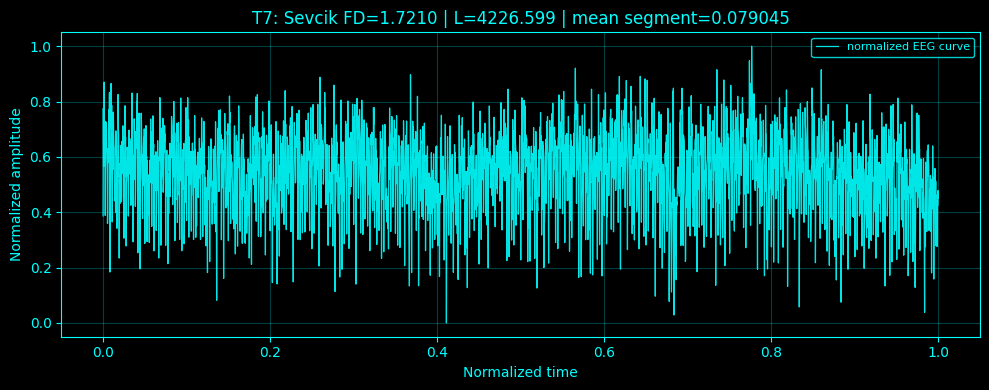

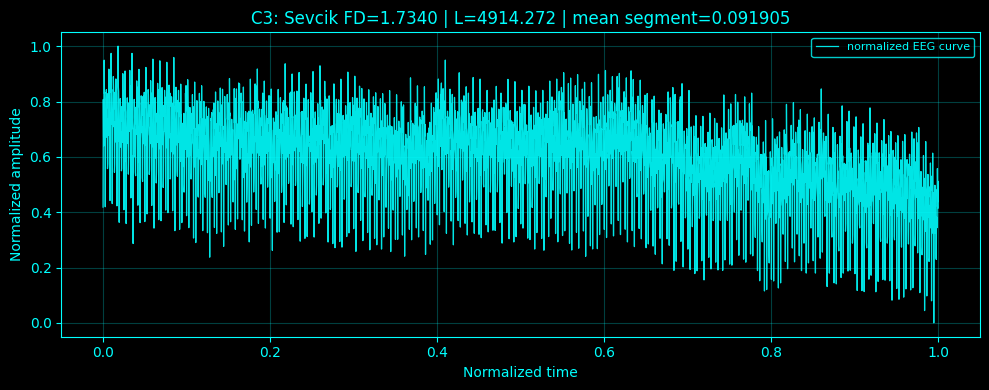

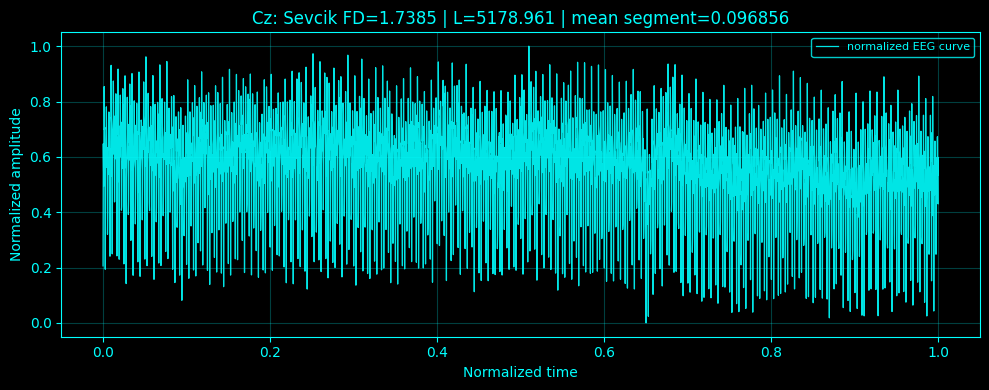

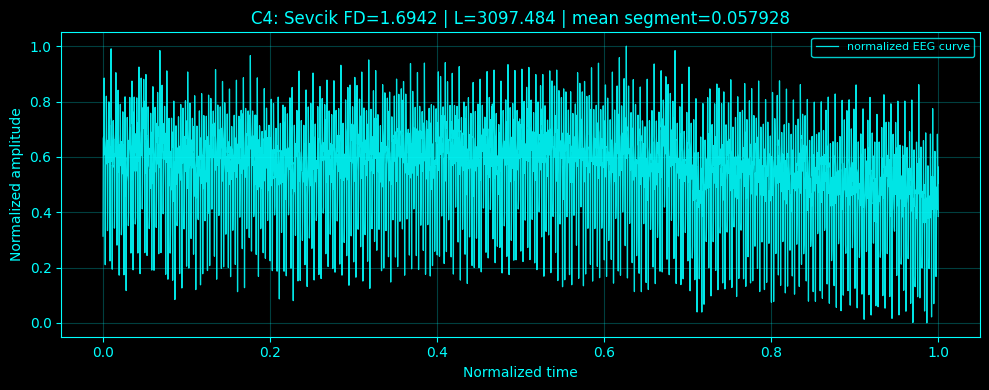

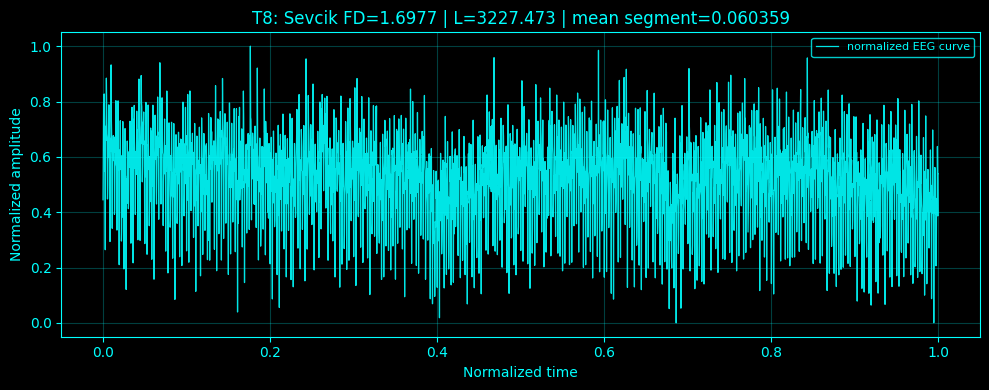

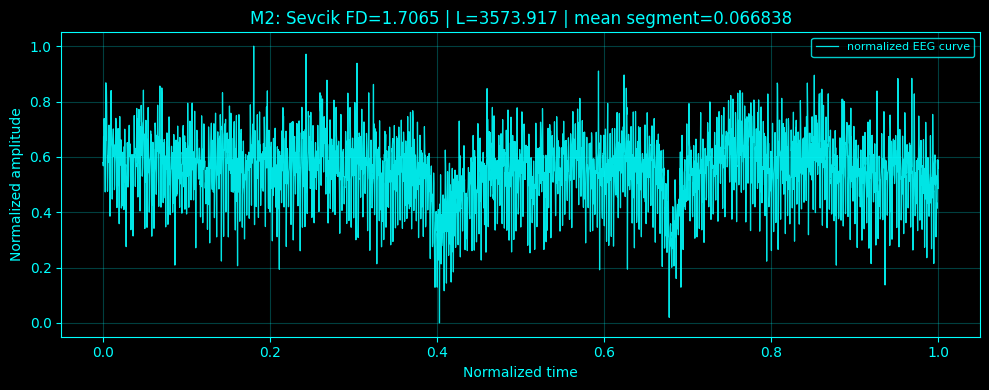

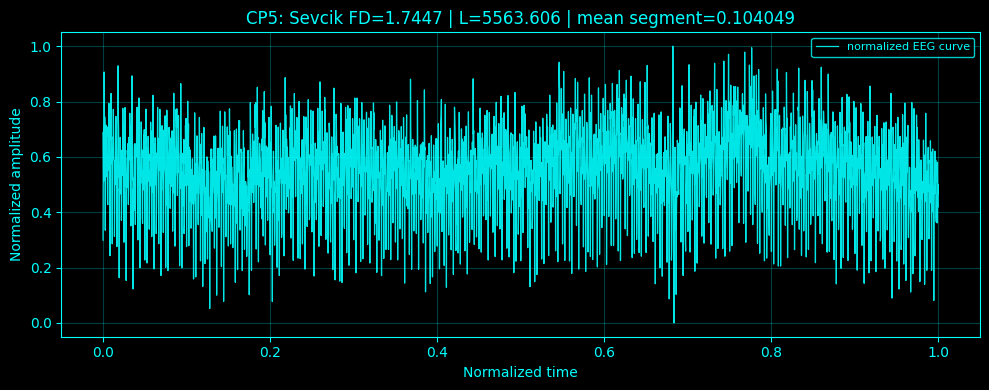

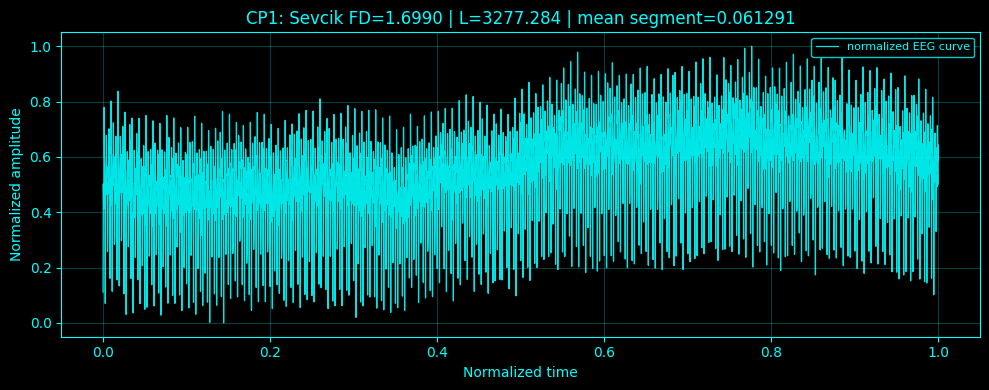

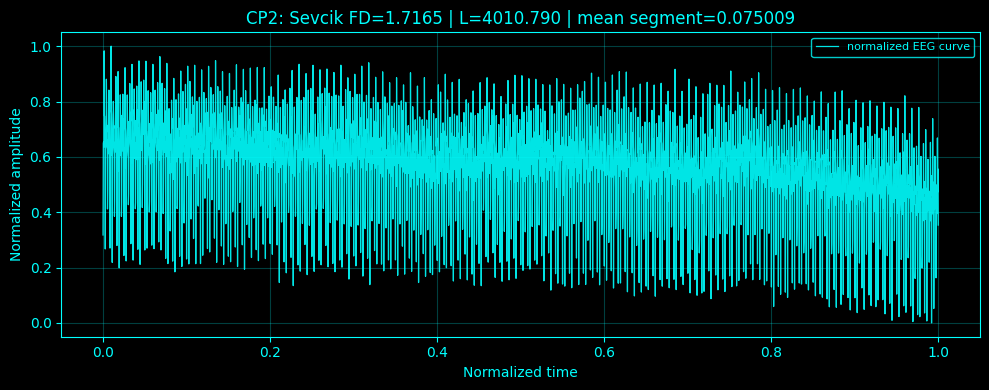

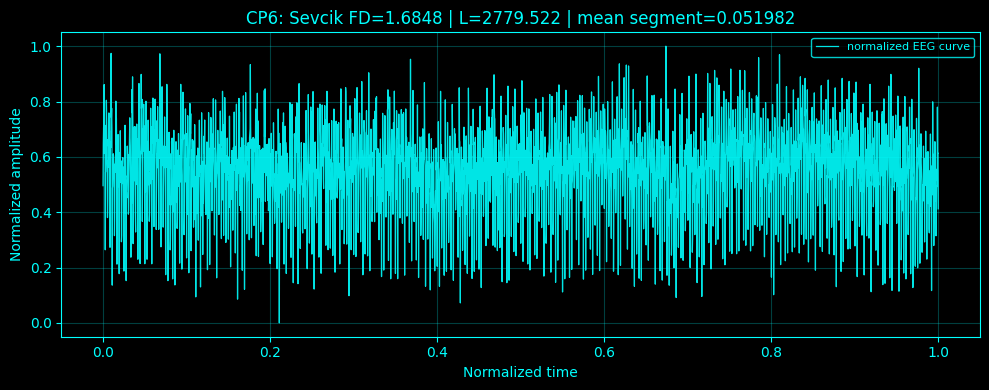

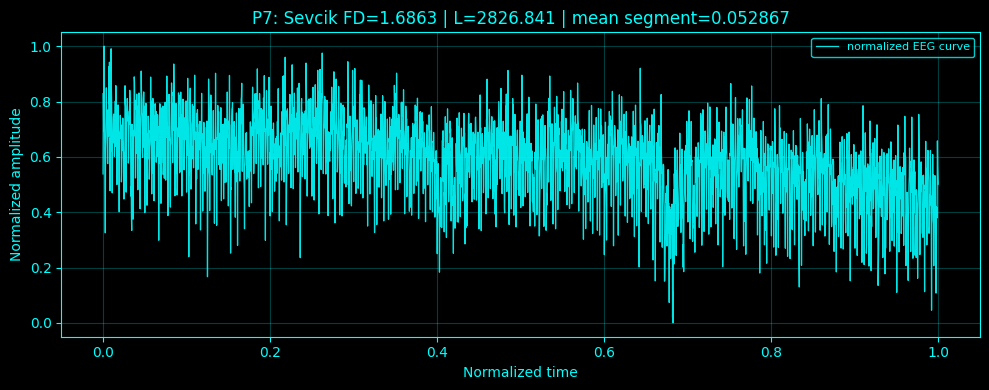

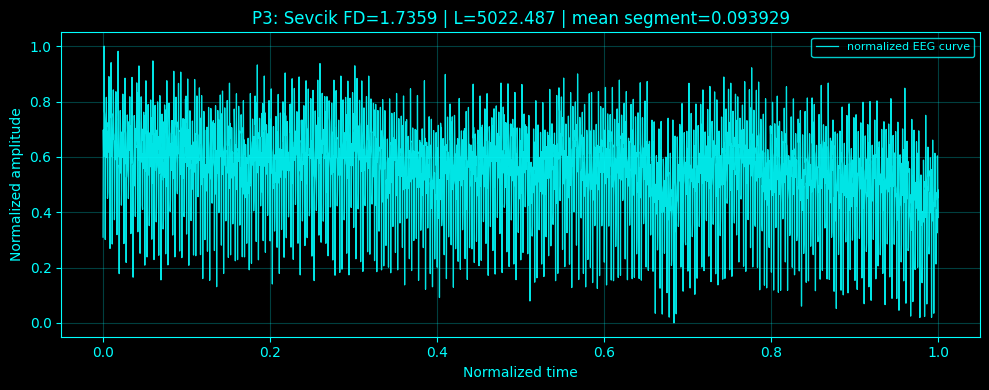

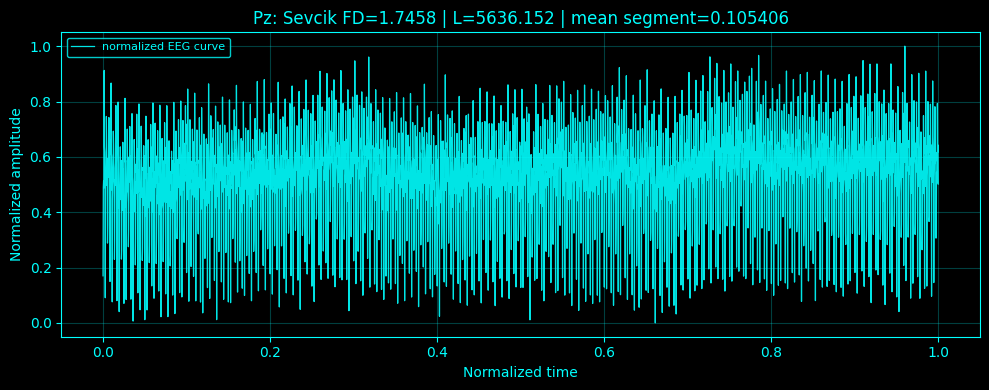

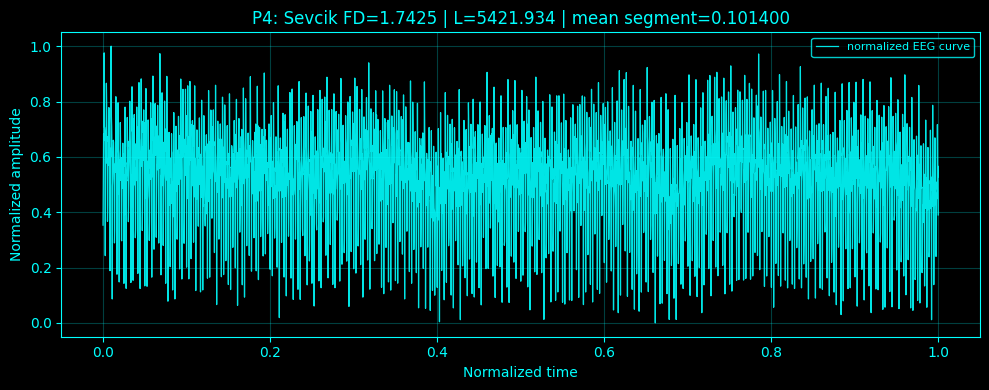

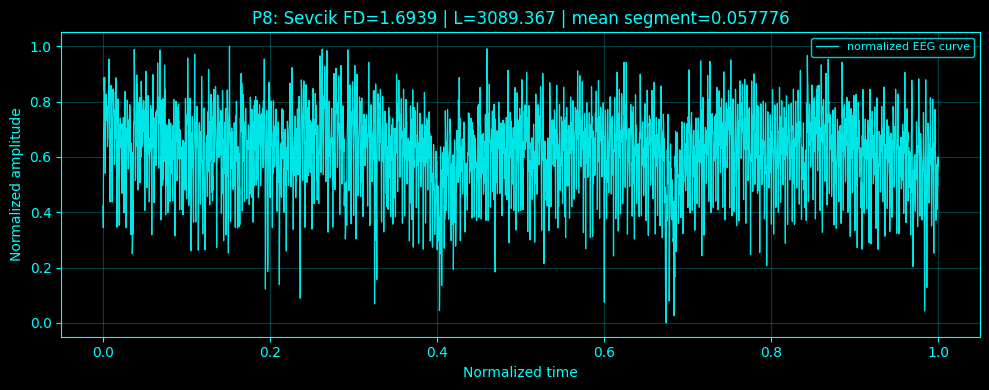

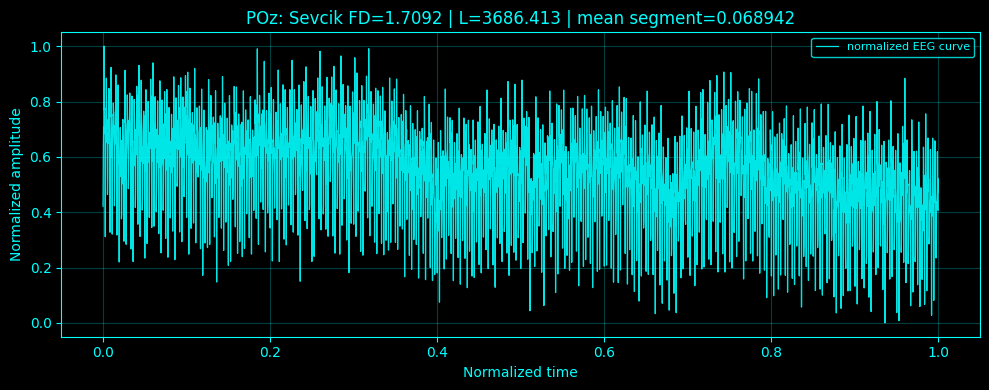

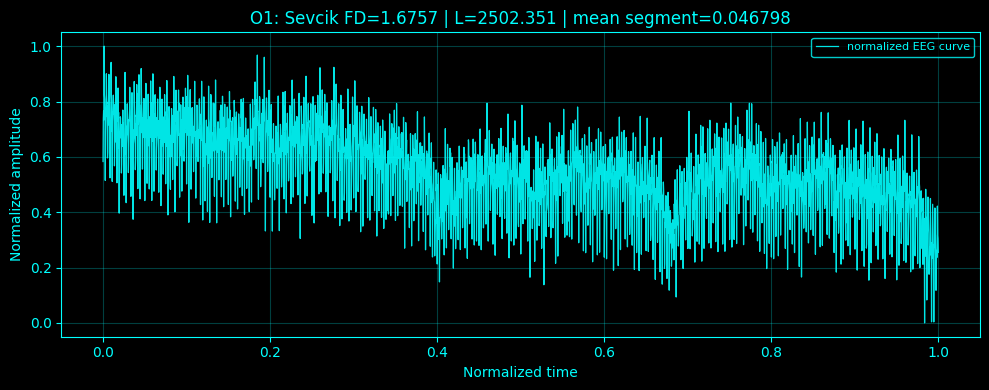

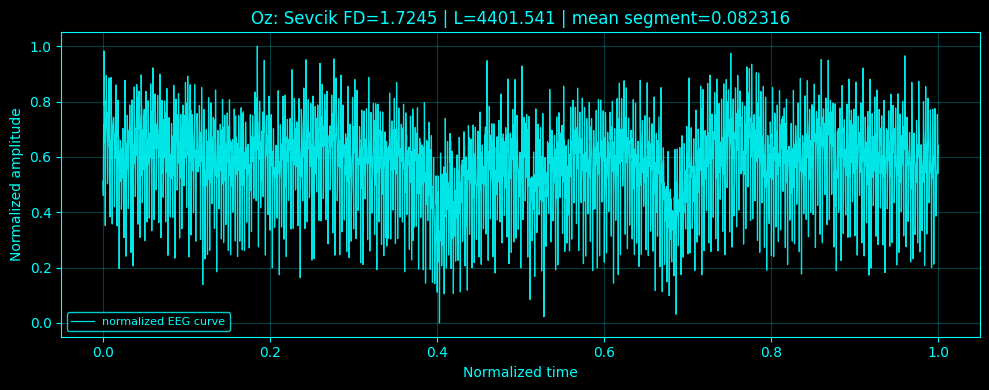

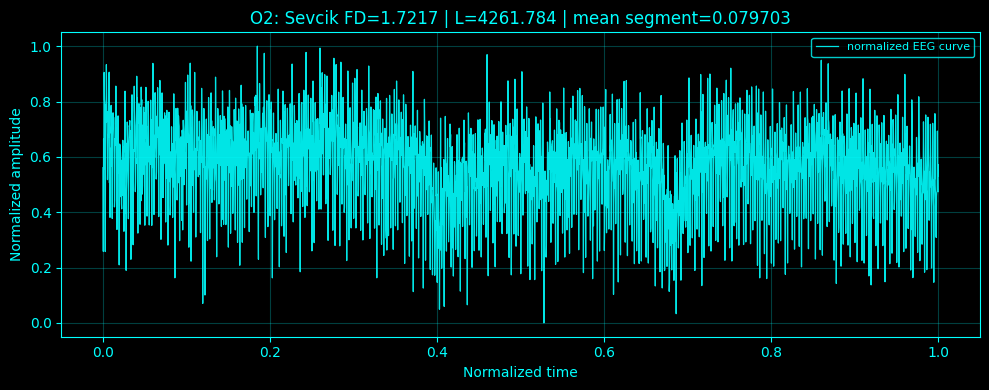

Per-channel Sevcik diagnostic plots saved to: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_sevcik/per_channel_sevcik_diagnostics


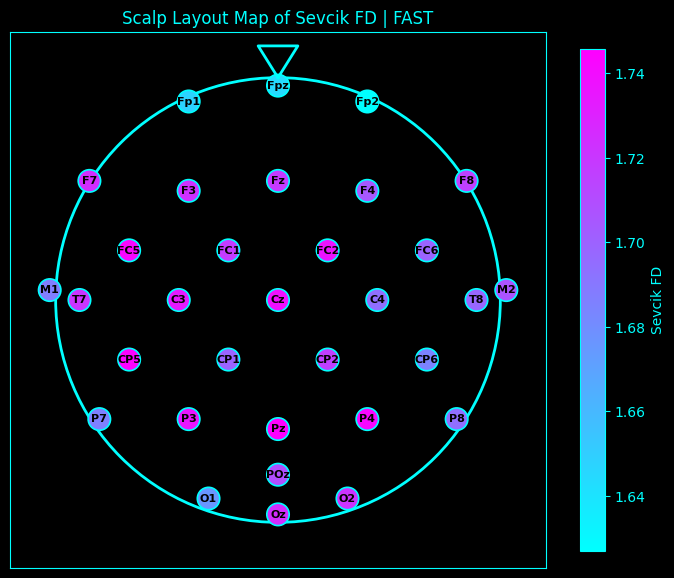

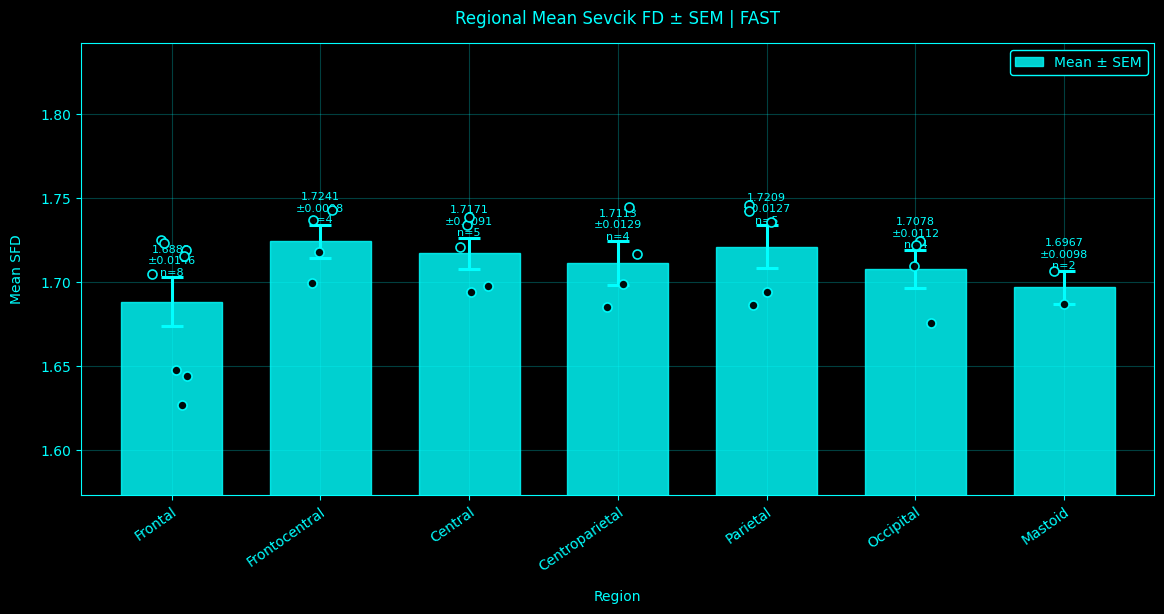

Regional summary plot saved to: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_sevcik/expert_plots_fast/regional_sevcik_fd_summary.png
Regional summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_sevcik/expert_plots_fast/regional_sevcik_fd_summary.csv
Regional channel-point CSV: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_sevcik/expert_plots_fast/regional_sevcik_fd_channel_points.csv


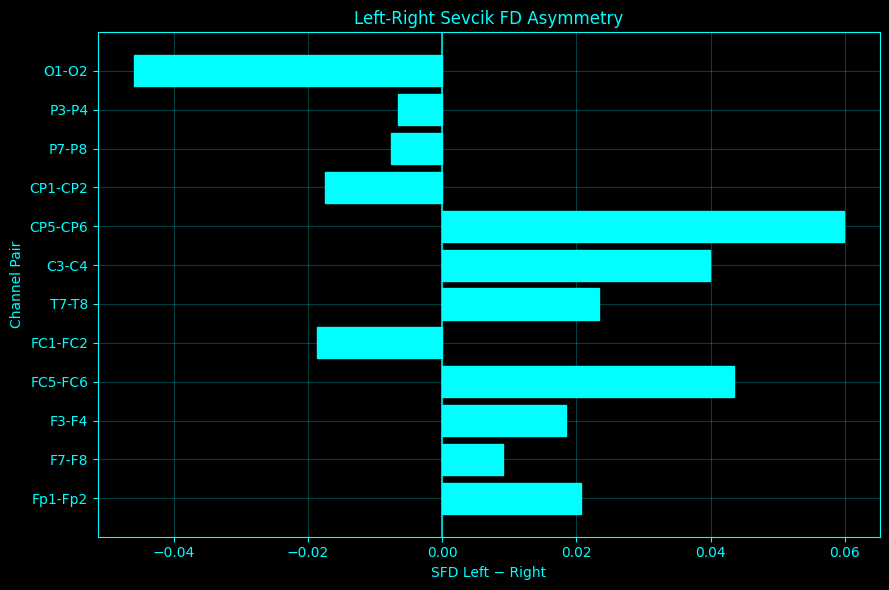

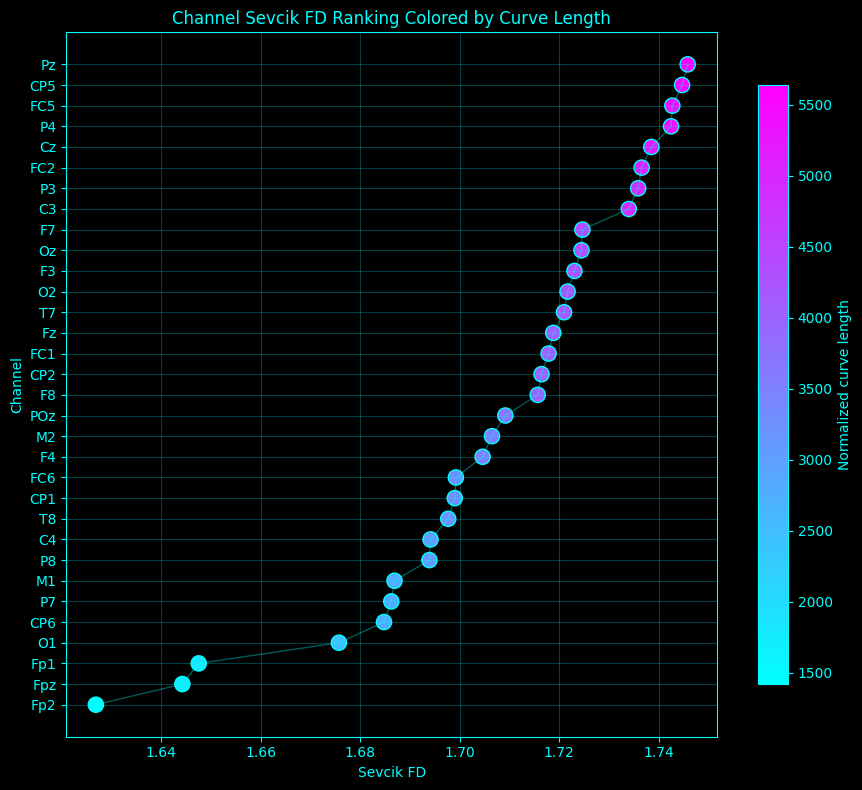

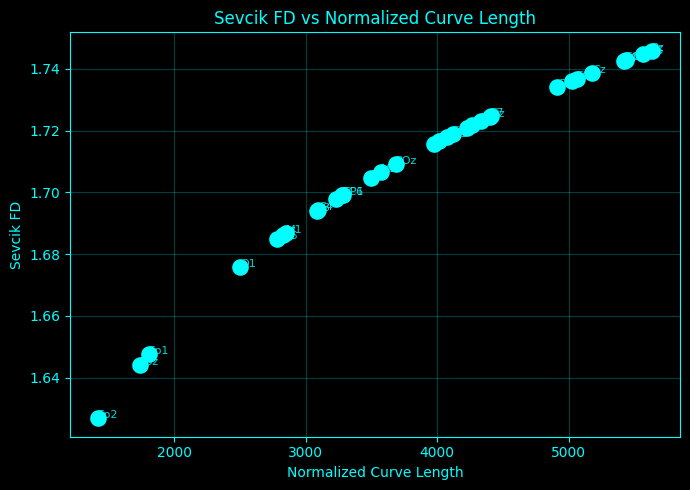

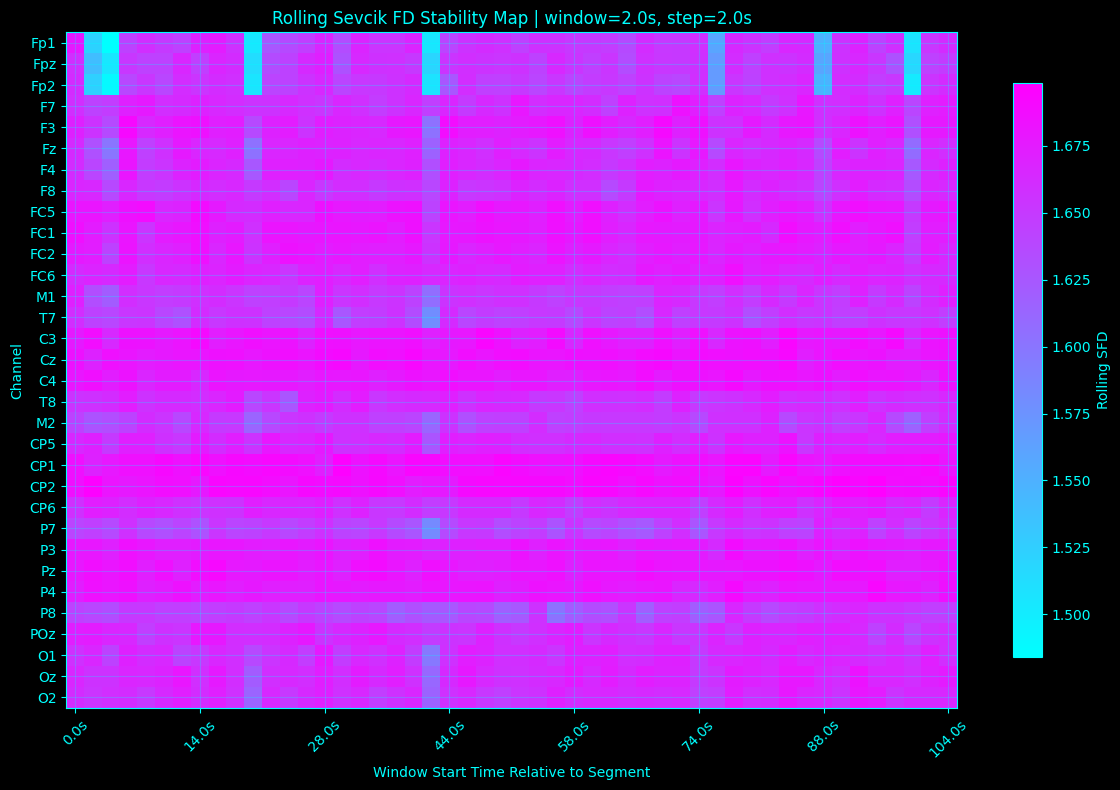

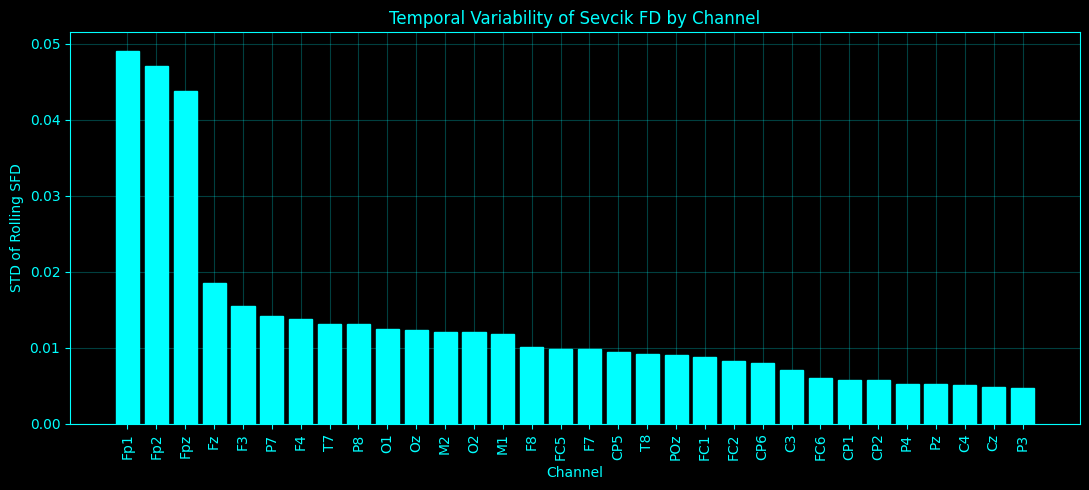

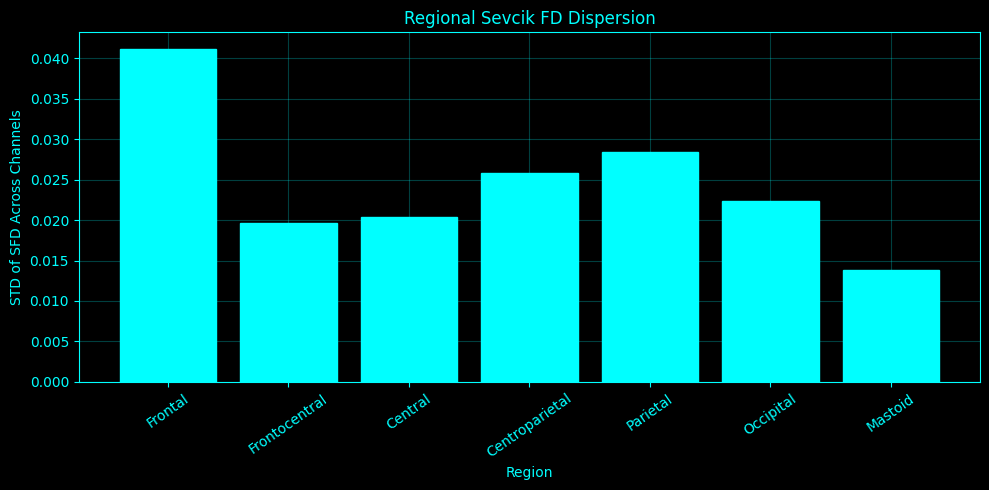

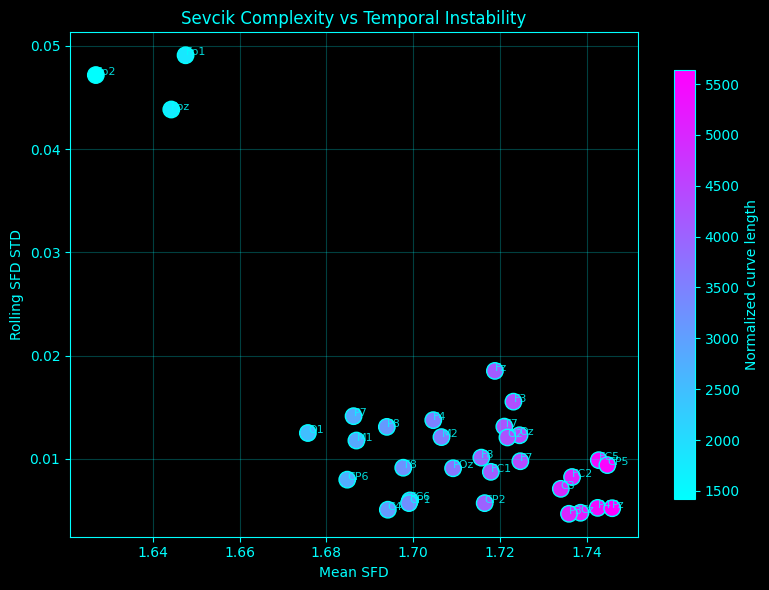


Expert plots saved to: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_sevcik/expert_plots_fast
Regional summary: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_sevcik/expert_plots_fast/regional_sevcik_fd_summary.csv
Asymmetry CSV: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_sevcik/expert_plots_fast/left_right_sevcik_fd_asymmetry.csv
Rolling SFD CSV: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_sevcik/expert_plots_fast/rolling_sevcik_fd_by_channel.csv
Rolling curve length CSV: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_sevcik/expert_plots_fast/rolling_sevcik_curve_length_by_channel.csv
Temporal variability CSV: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_sevcik/expert_plots_fast/rolling_sevcik_fd_temporal_variability.csv

Saved outputs to: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_sevcik
Summary CSV: /home/a/projects/Complete-Neura

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")
out_dir = os.path.join(base_dir, "fractal_dimension_sevcik")
os.makedirs(out_dir, exist_ok=True)

# Same segment used in your recent analyses
sampling_rate = 1000
start_time, end_time = 814.571, 921.515
start_idx = int(start_time * sampling_rate)
end_idx   = int(end_time * sampling_rate)

eeg_channels = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

# -------------------------------------------------------
# SPEED MODE
# -------------------------------------------------------
# Options:
#   "normal"    = highest fidelity
#   "fast"      = faster, mild downsampling/truncation
#   "ultrafast" = fastest exploratory scan
MODE = "fast"

MODE_CONFIGS = {
    "normal": {
        "decimate": 1,
        "max_samples": None,
        "rolling_window_sec": 2.0,
        "rolling_step_sec": 1.0,
        "rolling_max_windows": 100,
        "expert_plots": True,
    },
    "fast": {
        "decimate": 2,
        "max_samples": 60000,
        "rolling_window_sec": 2.0,
        "rolling_step_sec": 2.0,
        "rolling_max_windows": 50,
        "expert_plots": True,
    },
    "ultrafast": {
        "decimate": 5,
        "max_samples": 20000,
        "rolling_window_sec": 1.0,
        "rolling_step_sec": 3.0,
        "rolling_max_windows": 20,
        "expert_plots": True,
    },
}

if MODE not in MODE_CONFIGS:
    raise ValueError(f"Unknown MODE={MODE}. Use one of: {list(MODE_CONFIGS)}")

mode_cfg = MODE_CONFIGS[MODE]

decimate = mode_cfg["decimate"]
max_samples = mode_cfg["max_samples"]

ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

print(f"\nRunning Sevcik FD in {MODE.upper()} mode")
print(f"decimate={decimate}, max_samples={max_samples}")

# -------------------------------------------------------
# STYLE HELPER
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.grid(True, alpha=0.25, color=ACCENT)
    ax.tick_params(colors=ACCENT)

    for spine in ax.spines.values():
        spine.set_color(ACCENT)

# -------------------------------------------------------
# LOAD EEG
# -------------------------------------------------------
EEG_data = np.load(eeg_path, allow_pickle=True)

if EEG_data.ndim != 2:
    raise ValueError(f"Expected 2D EEG array, got shape {EEG_data.shape}")

# Handle either (time, channels) or (channels, time)
if EEG_data.shape[1] == len(eeg_channels):
    EEG_segment = EEG_data[start_idx:end_idx, :]
elif EEG_data.shape[0] == len(eeg_channels):
    EEG_segment = EEG_data[:, start_idx:end_idx].T
else:
    raise ValueError(f"Unexpected EEG shape: {EEG_data.shape}")

n_time, n_channels = EEG_segment.shape
print(f"Loaded EEG segment: {n_time} samples x {n_channels} channels")
print(f"Segment: [{start_time}, {end_time}] sec")

# -------------------------------------------------------
# APPLY SPEED MODE PREPROCESSING
# -------------------------------------------------------
effective_sampling_rate = sampling_rate

if decimate > 1:
    EEG_segment = EEG_segment[::decimate, :]
    effective_sampling_rate = sampling_rate / decimate

if max_samples is not None and EEG_segment.shape[0] > max_samples:
    EEG_segment = EEG_segment[:max_samples, :]

n_time, n_channels = EEG_segment.shape

print(f"After {MODE.upper()} mode preprocessing:")
print(f"  Segment shape: {n_time} samples x {n_channels} channels")
print(f"  Effective sampling rate: {effective_sampling_rate:.2f} Hz")
print(f"  Effective duration: {n_time / effective_sampling_rate:.2f} sec")

# -------------------------------------------------------
# SEVCIK FRACTAL DIMENSION
# -------------------------------------------------------
def sevcik_fd(x):
    """
    Compute Sevcik Fractal Dimension for a 1D time series.

    Method:
      1. Normalize time to [0, 1].
      2. Normalize amplitude to [0, 1].
      3. Compute normalized curve length L.
      4. Estimate:
            SFD = 1 + log(L) / log(2 * (N - 1))

    Notes:
      - SFD is fast and curve-length based.
      - Values are usually close to 1 for smooth curves and increase with waveform roughness.
      - For flat signals, this returns 1.0.
    """
    x = np.asarray(x, dtype=float)
    N = len(x)

    if N < 3:
        return np.nan, {
            "n_samples": N,
            "normalized_curve_length": np.nan,
            "amplitude_range": np.nan,
            "mean_segment_length": np.nan,
            "curve_length_density": np.nan,
        }

    amp_min = np.nanmin(x)
    amp_max = np.nanmax(x)
    amp_range = amp_max - amp_min

    t_norm = np.linspace(0.0, 1.0, N)

    if not np.isfinite(amp_range) or amp_range <= 1e-12:
        y_norm = np.zeros_like(x, dtype=float)
        L = 1.0
        sfd = 1.0
    else:
        y_norm = (x - amp_min) / amp_range

        dx = np.diff(t_norm)
        dy = np.diff(y_norm)

        segment_lengths = np.sqrt(dx ** 2 + dy ** 2)
        L = np.sum(segment_lengths)

        if L <= 0 or not np.isfinite(L):
            sfd = np.nan
        else:
            sfd = 1.0 + np.log(L) / np.log(2.0 * (N - 1))

    mean_segment_length = L / max(N - 1, 1)
    curve_length_density = L / 1.0

    return sfd, {
        "n_samples": N,
        "normalized_curve_length": L,
        "amplitude_range": amp_range,
        "mean_segment_length": mean_segment_length,
        "curve_length_density": curve_length_density,
    }


def normalized_sevcik_curve(x):
    """
    Return normalized time, normalized amplitude, and segment lengths
    used by Sevcik FD.
    """
    x = np.asarray(x, dtype=float)
    N = len(x)

    if N < 3:
        return None, None, None

    t_norm = np.linspace(0.0, 1.0, N)

    amp_min = np.nanmin(x)
    amp_max = np.nanmax(x)
    amp_range = amp_max - amp_min

    if not np.isfinite(amp_range) or amp_range <= 1e-12:
        y_norm = np.zeros_like(x, dtype=float)
    else:
        y_norm = (x - amp_min) / amp_range

    dx = np.diff(t_norm)
    dy = np.diff(y_norm)
    segment_lengths = np.sqrt(dx ** 2 + dy ** 2)

    return t_norm, y_norm, segment_lengths

# -------------------------------------------------------
# RUN SEVCIK FD PER CHANNEL
# -------------------------------------------------------
rows = {}
diagnostic_rows = []

for ch_idx, ch_name in enumerate(eeg_channels):
    x = EEG_segment[:, ch_idx].astype(float)
    x = (x - np.mean(x)) / (np.std(x) + 1e-12)

    sfd, diag = sevcik_fd(x)

    rows[ch_name] = {
        "channel": ch_name,
        "sevcik_fd": sfd,
        "n_samples": diag["n_samples"],
        "normalized_curve_length": diag["normalized_curve_length"],
        "amplitude_range": diag["amplitude_range"],
        "mean_segment_length": diag["mean_segment_length"],
        "curve_length_density": diag["curve_length_density"],
    }

    diagnostic_rows.append(rows[ch_name])

results_df = (
    pd.DataFrame(diagnostic_rows)
    .sort_values("sevcik_fd", ascending=False)
    .reset_index(drop=True)
)

csv_path = os.path.join(out_dir, "sevcik_fd_summary.csv")
results_df.to_csv(csv_path, index=False)

print("\nSevcik Fractal Dimensions:")
print(results_df)

# -------------------------------------------------------
# SAVE DIAGNOSTIC TABLE
# -------------------------------------------------------
diagnostics_df = results_df.copy()

diagnostics_csv_path = os.path.join(out_dir, "sevcik_fd_diagnostics.csv")
diagnostics_df.to_csv(diagnostics_csv_path, index=False)

print(f"\nDiagnostics CSV: {diagnostics_csv_path}")

# -------------------------------------------------------
# PLOT 1: FIXED SFD BY CHANNEL PLOT
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(13, 5.8), facecolor=BG)
style_ax(ax)

plot_df = results_df.copy().sort_values("sevcik_fd", ascending=False).reset_index(drop=True)

x_pos = np.arange(len(plot_df))
y = plot_df["sevcik_fd"].to_numpy(dtype=float)

y_min = np.nanmin(y)
y_max = np.nanmax(y)
y_range = y_max - y_min

if not np.isfinite(y_range) or y_range <= 0:
    y_range = 0.001

pad = max(0.0005, y_range * 0.35)
baseline = y_min - pad * 0.6

# Lollipop stems make small SFD differences visible without implying a zero baseline
ax.vlines(
    x_pos,
    baseline,
    y,
    color=ACCENT,
    linewidth=1.8,
    alpha=0.75
)

ax.scatter(
    x_pos,
    y,
    s=85,
    facecolors=BG,
    edgecolors=ACCENT,
    linewidths=1.8,
    zorder=4,
    label="Sevcik FD"
)

mean_sfd = np.nanmean(y)

ax.axhline(
    mean_sfd,
    color=ACCENT,
    linestyle="--",
    linewidth=1.4,
    alpha=0.75,
    label=f"Mean={mean_sfd:.5f}"
)

# Label strongest and weakest channels
top_n = min(4, len(plot_df))
label_indices = list(range(top_n)) + list(range(len(plot_df) - top_n, len(plot_df)))

for i in sorted(set(label_indices)):
    ax.text(
        x_pos[i],
        y[i] + pad * 0.12,
        f"{y[i]:.5f}",
        ha="center",
        va="bottom",
        fontsize=7,
        color=ACCENT,
        rotation=90
    )

ax.set_ylim(baseline, y_max + pad * 1.3)

ax.set_title(f"Sevcik Fractal Dimension by Channel | {MODE.upper()}", pad=12)
ax.set_xlabel("Channel")
ax.set_ylabel("SFD")

ax.set_xticks(x_pos)
ax.set_xticklabels(plot_df["channel"], rotation=90)

ax.legend(loc="best", framealpha=1.0)

bar_path = os.path.join(out_dir, "sevcik_fd_barplot.png")
plt.tight_layout()
plt.savefig(bar_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 2: ALL-CHANNEL NORMALIZED CURVE DIAGNOSTICS
# -------------------------------------------------------
n_cols = 4
n_rows = int(np.ceil(len(eeg_channels) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4 * n_cols, 3.5 * n_rows),
    facecolor=BG
)

axes = axes.flatten()

samples_to_plot = min(1200, n_time)

for ax_idx, ch_name in enumerate(eeg_channels):
    ax = axes[ax_idx]
    style_ax(ax)

    ch_idx = eeg_channels.index(ch_name)

    x_raw = EEG_segment[:samples_to_plot, ch_idx].astype(float)
    x_raw = (x_raw - np.mean(x_raw)) / (np.std(x_raw) + 1e-12)

    t_norm, y_norm, segment_lengths = normalized_sevcik_curve(x_raw)

    sfd_val = rows[ch_name]["sevcik_fd"]
    L_val = rows[ch_name]["normalized_curve_length"]

    if t_norm is not None:
        ax.plot(
            t_norm,
            y_norm,
            color=ACCENT,
            linewidth=0.9,
            alpha=0.9,
            label="normalized curve"
        )

    ax.set_title(f"{ch_name}: SFD={sfd_val:.4f}")
    ax.set_xlabel("Normalized time")
    ax.set_ylabel("Normalized amplitude")

    if np.isfinite(L_val):
        ax.text(
            0.02,
            0.95,
            f"L={L_val:.3f}",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=8,
            color=ACCENT
        )

# Turn off unused axes if any
for j in range(len(eeg_channels), len(axes)):
    axes[j].axis("off")

all_diag_path = os.path.join(out_dir, "all_channels_sevcik_normalized_curve_diagnostics.png")
plt.tight_layout()
plt.savefig(all_diag_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

print(f"All-channel Sevcik diagnostic plot saved to: {all_diag_path}")

# -------------------------------------------------------
# OPTIONAL: SAVE ONE DIAGNOSTIC PLOT PER CHANNEL
# -------------------------------------------------------
per_channel_dir = os.path.join(out_dir, "per_channel_sevcik_diagnostics")
os.makedirs(per_channel_dir, exist_ok=True)

samples_to_plot = min(3000, n_time)

for ch_name in eeg_channels:
    ch_idx = eeg_channels.index(ch_name)

    x_raw = EEG_segment[:samples_to_plot, ch_idx].astype(float)
    x_raw = (x_raw - np.mean(x_raw)) / (np.std(x_raw) + 1e-12)

    t_norm, y_norm, segment_lengths = normalized_sevcik_curve(x_raw)

    sfd_val = rows[ch_name]["sevcik_fd"]
    L_val = rows[ch_name]["normalized_curve_length"]
    mean_seg = rows[ch_name]["mean_segment_length"]

    fig, ax = plt.subplots(figsize=(10, 4), facecolor=BG)
    style_ax(ax)

    if t_norm is not None:
        ax.plot(
            t_norm,
            y_norm,
            color=ACCENT,
            linewidth=0.9,
            alpha=0.9,
            label="normalized EEG curve"
        )

    ax.set_title(
        f"{ch_name}: Sevcik FD={sfd_val:.4f} | "
        f"L={L_val:.3f} | mean segment={mean_seg:.6f}"
    )

    ax.set_xlabel("Normalized time")
    ax.set_ylabel("Normalized amplitude")
    ax.legend(fontsize=8)

    diag_path = os.path.join(per_channel_dir, f"{ch_name}_sevcik_diagnostic.png")
    plt.tight_layout()
    plt.savefig(diag_path, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close()

print(f"Per-channel Sevcik diagnostic plots saved to: {per_channel_dir}")

# -------------------------------------------------------
# SAVE ALL VALUES
# -------------------------------------------------------
npz_path = os.path.join(out_dir, "sevcik_fd_values.npz")

save_dict = {
    "channels": np.asarray(eeg_channels),
    "sevcik_fd": np.asarray([rows[ch]["sevcik_fd"] for ch in eeg_channels], dtype=float),
    "normalized_curve_length": np.asarray(
        [rows[ch]["normalized_curve_length"] for ch in eeg_channels],
        dtype=float
    ),
    "amplitude_range": np.asarray(
        [rows[ch]["amplitude_range"] for ch in eeg_channels],
        dtype=float
    ),
    "mean_segment_length": np.asarray(
        [rows[ch]["mean_segment_length"] for ch in eeg_channels],
        dtype=float
    ),
    "curve_length_density": np.asarray(
        [rows[ch]["curve_length_density"] for ch in eeg_channels],
        dtype=float
    ),
}

np.savez(npz_path, **save_dict)

# -------------------------------------------------------
# EXPERT-LEVEL ADDITIONAL PLOTS
# -------------------------------------------------------
if mode_cfg["expert_plots"]:

    expert_dir = os.path.join(out_dir, f"expert_plots_{MODE}")
    os.makedirs(expert_dir, exist_ok=True)

    sfd_map = dict(zip(results_df["channel"], results_df["sevcik_fd"]))
    curve_length_map = dict(zip(results_df["channel"], results_df["normalized_curve_length"]))
    mean_segment_map = dict(zip(results_df["channel"], results_df["mean_segment_length"]))

    # ---------------------------------------------------
    # PLOT 3: SCALP-LAYOUT SFD MAP
    # ---------------------------------------------------
    scalp_xy = {
        "Fp1": (-0.45, 1.00), "Fpz": (0.00, 1.08), "Fp2": (0.45, 1.00),
        "F7": (-0.95, 0.60), "F3": (-0.45, 0.55), "Fz": (0.00, 0.60),
        "F4": (0.45, 0.55), "F8": (0.95, 0.60),

        "FC5": (-0.75, 0.25), "FC1": (-0.25, 0.25),
        "FC2": (0.25, 0.25), "FC6": (0.75, 0.25),

        "M1": (-1.15, 0.05), "T7": (-1.00, 0.00), "C3": (-0.50, 0.00),
        "Cz": (0.00, 0.00), "C4": (0.50, 0.00), "T8": (1.00, 0.00),
        "M2": (1.15, 0.05),

        "CP5": (-0.75, -0.30), "CP1": (-0.25, -0.30),
        "CP2": (0.25, -0.30), "CP6": (0.75, -0.30),

        "P7": (-0.90, -0.60), "P3": (-0.45, -0.60), "Pz": (0.00, -0.65),
        "P4": (0.45, -0.60), "P8": (0.90, -0.60),

        "POz": (0.00, -0.88),
        "O1": (-0.35, -1.00), "Oz": (0.00, -1.08), "O2": (0.35, -1.00),
    }

    xs, ys, vals, labels = [], [], [], []

    for ch in eeg_channels:
        if ch in scalp_xy and ch in sfd_map and np.isfinite(sfd_map[ch]):
            xs.append(scalp_xy[ch][0])
            ys.append(scalp_xy[ch][1])
            vals.append(sfd_map[ch])
            labels.append(ch)

    fig, ax = plt.subplots(figsize=(7, 7), facecolor=BG)
    style_ax(ax)

    head = plt.Circle((0, 0), 1.12, fill=False, color=ACCENT, linewidth=2)
    ax.add_patch(head)

    nose_x = [0.00, -0.10, 0.10, 0.00]
    nose_y = [1.12, 1.28, 1.28, 1.12]
    ax.plot(nose_x, nose_y, color=ACCENT, linewidth=2)

    sc = ax.scatter(
        xs,
        ys,
        c=vals,
        s=260,
        cmap="cool",
        edgecolor=ACCENT,
        linewidth=1.2
    )

    for x0, y0, label in zip(xs, ys, labels):
        ax.text(
            x0,
            y0,
            label,
            ha="center",
            va="center",
            fontsize=8,
            color=BG,
            fontweight="bold"
        )

    cbar = plt.colorbar(sc, ax=ax, shrink=0.75)
    cbar.set_label("Sevcik FD", color=ACCENT)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)

    ax.set_title(f"Scalp Layout Map of Sevcik FD | {MODE.upper()}")
    ax.set_xlim(-1.35, 1.35)
    ax.set_ylim(-1.35, 1.35)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])

    scalp_path = os.path.join(expert_dir, "sevcik_fd_scalp_layout_map.png")
    plt.tight_layout()
    plt.savefig(scalp_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

    # ---------------------------------------------------
    # PLOT 4: REGIONAL SFD SUMMARY
    # ---------------------------------------------------
    regions = {
        "Frontal": ["Fp1", "Fpz", "Fp2", "F7", "F3", "Fz", "F4", "F8"],
        "Frontocentral": ["FC5", "FC1", "FC2", "FC6"],
        "Central": ["T7", "C3", "Cz", "C4", "T8"],
        "Centroparietal": ["CP5", "CP1", "CP2", "CP6"],
        "Parietal": ["P7", "P3", "Pz", "P4", "P8"],
        "Occipital": ["POz", "O1", "Oz", "O2"],
        "Mastoid": ["M1", "M2"],
    }

    region_rows = []
    region_points = []

    for region_name, chans in regions.items():
        vals_region = []

        for ch in chans:
            if ch in sfd_map and np.isfinite(sfd_map[ch]):
                vals_region.append(sfd_map[ch])
                region_points.append({
                    "region": region_name,
                    "channel": ch,
                    "sfd": sfd_map[ch],
                })

        if len(vals_region) == 0:
            continue

        vals_region = np.asarray(vals_region, dtype=float)

        region_rows.append({
            "region": region_name,
            "mean_sfd": np.mean(vals_region),
            "std_sfd": np.std(vals_region, ddof=1) if len(vals_region) > 1 else 0.0,
            "sem_sfd": (
                np.std(vals_region, ddof=1) / np.sqrt(len(vals_region))
                if len(vals_region) > 1 else 0.0
            ),
            "n_channels": len(vals_region),
        })

    region_df = pd.DataFrame(region_rows)
    region_points_df = pd.DataFrame(region_points)

    region_csv_path = os.path.join(expert_dir, "regional_sevcik_fd_summary.csv")
    region_df.to_csv(region_csv_path, index=False)

    region_points_csv_path = os.path.join(expert_dir, "regional_sevcik_fd_channel_points.csv")
    region_points_df.to_csv(region_points_csv_path, index=False)

    fig, ax = plt.subplots(figsize=(12, 6.5), facecolor=BG)
    style_ax(ax)

    x_region = np.arange(len(region_df))

    ax.bar(
        x_region,
        region_df["mean_sfd"],
        yerr=region_df["sem_sfd"],
        color=ACCENT,
        edgecolor=ACCENT,
        alpha=0.82,
        width=0.68,
        capsize=8,
        error_kw={
            "elinewidth": 2.2,
            "capthick": 2.2,
            "ecolor": ACCENT,
            "alpha": 1.0,
        },
        label="Mean ± SEM"
    )

    rng = np.random.default_rng(7)

    for i, region_name in enumerate(region_df["region"]):
        vals = region_points_df.loc[
            region_points_df["region"] == region_name,
            "sfd"
        ].to_numpy(dtype=float)

        if len(vals) == 0:
            continue

        jitter = rng.uniform(-0.13, 0.13, size=len(vals))

        ax.scatter(
            np.full(len(vals), i) + jitter,
            vals,
            s=42,
            facecolors=BG,
            edgecolors=ACCENT,
            linewidths=1.2,
            alpha=0.95,
            zorder=4
        )

    for i, row in region_df.iterrows():
        y_val = row["mean_sfd"]
        sem = row["sem_sfd"]

        ax.text(
            i,
            y_val + sem,
            f"{y_val:.4f}\n±{sem:.4f}\nn={int(row['n_channels'])}",
            ha="center",
            va="bottom",
            fontsize=8,
            color=ACCENT
        )

    all_region_vals = region_points_df["sfd"].to_numpy(dtype=float)
    all_sem_upper = region_df["mean_sfd"].to_numpy(dtype=float) + region_df["sem_sfd"].to_numpy(dtype=float)
    all_sem_lower = region_df["mean_sfd"].to_numpy(dtype=float) - region_df["sem_sfd"].to_numpy(dtype=float)

    y_min = np.nanmin(np.concatenate([all_region_vals, all_sem_lower]))
    y_max = np.nanmax(np.concatenate([all_region_vals, all_sem_upper]))

    y_range = y_max - y_min
    if not np.isfinite(y_range) or y_range <= 0:
        y_range = 0.01

    pad = max(0.0025, y_range * 0.45)

    ax.set_ylim(y_min - pad, y_max + pad * 1.8)

    ax.set_title(f"Regional Mean Sevcik FD ± SEM | {MODE.upper()}", pad=14)
    ax.set_xlabel("Region", labelpad=12)
    ax.set_ylabel("Mean SFD", labelpad=12)

    ax.set_xticks(x_region)
    ax.set_xticklabels(
        region_df["region"],
        rotation=35,
        ha="right",
        rotation_mode="anchor"
    )

    ax.margins(x=0.04)
    ax.legend(loc="best", framealpha=1.0)

    region_path = os.path.join(expert_dir, "regional_sevcik_fd_summary.png")
    plt.tight_layout(pad=2.0)
    plt.savefig(region_path, dpi=220, bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"Regional summary plot saved to: {region_path}")
    print(f"Regional summary CSV: {region_csv_path}")
    print(f"Regional channel-point CSV: {region_points_csv_path}")

    # ---------------------------------------------------
    # PLOT 5: LEFT-RIGHT ASYMMETRY
    # ---------------------------------------------------
    lr_pairs = [
        ("Fp1", "Fp2"),
        ("F7", "F8"),
        ("F3", "F4"),
        ("FC5", "FC6"),
        ("FC1", "FC2"),
        ("T7", "T8"),
        ("C3", "C4"),
        ("CP5", "CP6"),
        ("CP1", "CP2"),
        ("P7", "P8"),
        ("P3", "P4"),
        ("O1", "O2"),
    ]

    asym_rows = []

    for left_ch, right_ch in lr_pairs:
        if left_ch in sfd_map and right_ch in sfd_map:
            left_val = sfd_map[left_ch]
            right_val = sfd_map[right_ch]

            if np.isfinite(left_val) and np.isfinite(right_val):
                asym_rows.append({
                    "pair": f"{left_ch}-{right_ch}",
                    "left_channel": left_ch,
                    "right_channel": right_ch,
                    "left_sfd": left_val,
                    "right_sfd": right_val,
                    "asymmetry_left_minus_right": left_val - right_val,
                })

    asym_df = pd.DataFrame(asym_rows)
    asym_csv_path = os.path.join(expert_dir, "left_right_sevcik_fd_asymmetry.csv")
    asym_df.to_csv(asym_csv_path, index=False)

    fig, ax = plt.subplots(figsize=(9, 6), facecolor=BG)
    style_ax(ax)

    ax.axvline(0, color=ACCENT, linewidth=1.5, alpha=0.75)

    ax.barh(
        asym_df["pair"],
        asym_df["asymmetry_left_minus_right"],
        color=ACCENT,
        edgecolor=ACCENT
    )

    ax.set_title("Left-Right Sevcik FD Asymmetry")
    ax.set_xlabel("SFD Left − Right")
    ax.set_ylabel("Channel Pair")

    asym_path = os.path.join(expert_dir, "left_right_sevcik_fd_asymmetry.png")
    plt.tight_layout()
    plt.savefig(asym_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

    # ---------------------------------------------------
    # PLOT 6: SFD RANKING COLORED BY NORMALIZED CURVE LENGTH
    # ---------------------------------------------------
    rank_df = diagnostics_df.copy()
    rank_df = rank_df.sort_values("sevcik_fd", ascending=True).reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(9, 8), facecolor=BG)
    style_ax(ax)

    sc = ax.scatter(
        rank_df["sevcik_fd"],
        rank_df["channel"],
        c=rank_df["normalized_curve_length"],
        s=120,
        cmap="cool",
        edgecolor=ACCENT,
        linewidth=1.0
    )

    ax.plot(
        rank_df["sevcik_fd"],
        rank_df["channel"],
        color=ACCENT,
        alpha=0.35,
        linewidth=1.0
    )

    cbar = plt.colorbar(sc, ax=ax, shrink=0.85)
    cbar.set_label("Normalized curve length", color=ACCENT)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)

    ax.set_title("Channel Sevcik FD Ranking Colored by Curve Length")
    ax.set_xlabel("Sevcik FD")
    ax.set_ylabel("Channel")

    ranking_path = os.path.join(expert_dir, "sevcik_fd_ranking_curve_length.png")
    plt.tight_layout()
    plt.savefig(ranking_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

    # ---------------------------------------------------
    # PLOT 7: SFD VS NORMALIZED CURVE LENGTH
    # ---------------------------------------------------
    fig, ax = plt.subplots(figsize=(7, 5), facecolor=BG)
    style_ax(ax)

    ax.scatter(
        diagnostics_df["normalized_curve_length"],
        diagnostics_df["sevcik_fd"],
        s=120,
        color=ACCENT,
        edgecolor=ACCENT
    )

    for _, row in diagnostics_df.iterrows():
        if np.isfinite(row["normalized_curve_length"]) and np.isfinite(row["sevcik_fd"]):
            ax.text(
                row["normalized_curve_length"],
                row["sevcik_fd"],
                row["channel"],
                fontsize=8,
                color=ACCENT,
                alpha=0.85
            )

    ax.set_title("Sevcik FD vs Normalized Curve Length")
    ax.set_xlabel("Normalized Curve Length")
    ax.set_ylabel("Sevcik FD")

    curve_length_path = os.path.join(expert_dir, "sevcik_fd_vs_normalized_curve_length.png")
    plt.tight_layout()
    plt.savefig(curve_length_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

    # ---------------------------------------------------
    # PLOT 8: TEMPORAL STABILITY HEATMAP
    # ---------------------------------------------------
    rolling_window_samples = int(mode_cfg["rolling_window_sec"] * effective_sampling_rate)
    rolling_step_samples = int(mode_cfg["rolling_step_sec"] * effective_sampling_rate)

    rolling_window_samples = max(rolling_window_samples, 8)
    rolling_step_samples = max(rolling_step_samples, 1)

    possible_starts = np.arange(
        0,
        max(1, n_time - rolling_window_samples + 1),
        rolling_step_samples
    )

    if len(possible_starts) > mode_cfg["rolling_max_windows"]:
        chosen_idx = np.linspace(
            0,
            len(possible_starts) - 1,
            mode_cfg["rolling_max_windows"]
        ).astype(int)

        possible_starts = possible_starts[chosen_idx]

    rolling_sfd = np.full((len(eeg_channels), len(possible_starts)), np.nan)
    rolling_curve_length = np.full((len(eeg_channels), len(possible_starts)), np.nan)

    for w_idx, s0 in enumerate(possible_starts):
        s1 = s0 + rolling_window_samples

        for ch_idx, ch_name in enumerate(eeg_channels):
            xw = EEG_segment[s0:s1, ch_idx].astype(float)
            xw = (xw - np.mean(xw)) / (np.std(xw) + 1e-12)

            sfd_w, diag_w = sevcik_fd(xw)
            rolling_sfd[ch_idx, w_idx] = sfd_w
            rolling_curve_length[ch_idx, w_idx] = diag_w["normalized_curve_length"]

    rolling_times = possible_starts / effective_sampling_rate

    rolling_df = pd.DataFrame(
        rolling_sfd,
        index=eeg_channels,
        columns=[f"{t:.3f}s" for t in rolling_times]
    )

    rolling_csv_path = os.path.join(expert_dir, "rolling_sevcik_fd_by_channel.csv")
    rolling_df.to_csv(rolling_csv_path)

    rolling_curve_df = pd.DataFrame(
        rolling_curve_length,
        index=eeg_channels,
        columns=[f"{t:.3f}s" for t in rolling_times]
    )

    rolling_curve_csv_path = os.path.join(expert_dir, "rolling_sevcik_curve_length_by_channel.csv")
    rolling_curve_df.to_csv(rolling_curve_csv_path)

    fig, ax = plt.subplots(figsize=(12, 8), facecolor=BG)
    style_ax(ax)

    im = ax.imshow(
        rolling_sfd,
        aspect="auto",
        interpolation="nearest",
        cmap="cool"
    )

    ax.set_title(
        f"Rolling Sevcik FD Stability Map | "
        f"window={mode_cfg['rolling_window_sec']}s, step={mode_cfg['rolling_step_sec']}s"
    )

    ax.set_xlabel("Window Start Time Relative to Segment")
    ax.set_ylabel("Channel")

    ax.set_yticks(np.arange(len(eeg_channels)))
    ax.set_yticklabels(eeg_channels)

    if len(rolling_times) > 0:
        xtick_idx = np.linspace(
            0,
            len(rolling_times) - 1,
            min(8, len(rolling_times))
        ).astype(int)

        ax.set_xticks(xtick_idx)
        ax.set_xticklabels(
            [f"{rolling_times[i]:.1f}s" for i in xtick_idx],
            rotation=45
        )

    cbar = plt.colorbar(im, ax=ax, shrink=0.85)
    cbar.set_label("Rolling SFD", color=ACCENT)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)

    rolling_path = os.path.join(expert_dir, "rolling_sevcik_fd_heatmap.png")
    plt.tight_layout()
    plt.savefig(rolling_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

    # ---------------------------------------------------
    # PLOT 9: TEMPORAL VARIABILITY BY CHANNEL
    # ---------------------------------------------------
    temporal_var = np.nanstd(rolling_sfd, axis=1)

    temporal_df = pd.DataFrame({
        "channel": eeg_channels,
        "rolling_sfd_std": temporal_var,
        "mean_sfd": [sfd_map[ch] for ch in eeg_channels],
        "normalized_curve_length": [curve_length_map[ch] for ch in eeg_channels],
    }).sort_values("rolling_sfd_std", ascending=False)

    temporal_csv_path = os.path.join(expert_dir, "rolling_sevcik_fd_temporal_variability.csv")
    temporal_df.to_csv(temporal_csv_path, index=False)

    fig, ax = plt.subplots(figsize=(11, 5), facecolor=BG)
    style_ax(ax)

    ax.bar(
        temporal_df["channel"],
        temporal_df["rolling_sfd_std"],
        color=ACCENT,
        edgecolor=ACCENT
    )

    ax.set_title("Temporal Variability of Sevcik FD by Channel")
    ax.set_xlabel("Channel")
    ax.set_ylabel("STD of Rolling SFD")
    ax.tick_params(axis="x", rotation=90)

    temporal_path = os.path.join(expert_dir, "rolling_sevcik_fd_temporal_variability.png")
    plt.tight_layout()
    plt.savefig(temporal_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

    # ---------------------------------------------------
    # PLOT 10: REGIONAL DISPERSION / HETEROGENEITY
    # ---------------------------------------------------
    fig, ax = plt.subplots(figsize=(10, 5), facecolor=BG)
    style_ax(ax)

    ax.bar(
        region_df["region"],
        region_df["std_sfd"],
        color=ACCENT,
        edgecolor=ACCENT
    )

    ax.set_title("Regional Sevcik FD Dispersion")
    ax.set_xlabel("Region")
    ax.set_ylabel("STD of SFD Across Channels")
    ax.tick_params(axis="x", rotation=35)

    dispersion_path = os.path.join(expert_dir, "regional_sevcik_fd_dispersion.png")
    plt.tight_layout()
    plt.savefig(dispersion_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

    # ---------------------------------------------------
    # PLOT 11: CHANNEL COMPLEXITY VS TEMPORAL INSTABILITY
    # ---------------------------------------------------
    fig, ax = plt.subplots(figsize=(8, 6), facecolor=BG)
    style_ax(ax)

    sc = ax.scatter(
        temporal_df["mean_sfd"],
        temporal_df["rolling_sfd_std"],
        c=temporal_df["normalized_curve_length"],
        s=140,
        cmap="cool",
        edgecolor=ACCENT,
        linewidth=1.0
    )

    for _, row in temporal_df.iterrows():
        if np.isfinite(row["mean_sfd"]) and np.isfinite(row["rolling_sfd_std"]):
            ax.text(
                row["mean_sfd"],
                row["rolling_sfd_std"],
                row["channel"],
                fontsize=8,
                color=ACCENT,
                alpha=0.85
            )

    cbar = plt.colorbar(sc, ax=ax, shrink=0.85)
    cbar.set_label("Normalized curve length", color=ACCENT)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)

    ax.set_title("Sevcik Complexity vs Temporal Instability")
    ax.set_xlabel("Mean SFD")
    ax.set_ylabel("Rolling SFD STD")

    instability_path = os.path.join(expert_dir, "sevcik_complexity_vs_temporal_instability.png")
    plt.tight_layout()
    plt.savefig(instability_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"\nExpert plots saved to: {expert_dir}")
    print(f"Regional summary: {region_csv_path}")
    print(f"Asymmetry CSV: {asym_csv_path}")
    print(f"Rolling SFD CSV: {rolling_csv_path}")
    print(f"Rolling curve length CSV: {rolling_curve_csv_path}")
    print(f"Temporal variability CSV: {temporal_csv_path}")

print(f"\nSaved outputs to: {out_dir}")
print(f"Summary CSV: {csv_path}")
print(f"Diagnostics CSV: {diagnostics_csv_path}")
print(f"Values NPZ: {npz_path}")


Running Hall-Wood FD in FAST mode
decimate=2, max_samples=60000, lags=[1, 2, 4, 8, 16, 32, 64]
Loaded EEG segment: 106944 samples x 32 channels
Segment: [814.571, 921.515] sec
After FAST mode preprocessing:
  Segment shape: 53472 samples x 32 channels
  Effective sampling rate: 500.00 Hz
  Effective duration: 106.94 sec

Hall-Wood Fractal Dimensions:
   channel  hall_wood_fd  scaling_slope  fit_intercept    fit_r2  fit_rmse  \
0      CP2      2.007693      -0.007693      -0.975458  0.001115  0.319197   
1      CP1      2.004883      -0.004883      -1.196035  0.000433  0.325410   
2       C4      2.004089      -0.004089      -1.358982  0.000387  0.288073   
3       Cz      2.003645      -0.003645      -0.483714  0.000280  0.301649   
4       P4      2.002927      -0.002927      -0.413397  0.000219  0.274033   
5       Pz      1.998974       0.001026      -0.273598  0.000021  0.308026   
6       O2      1.997814       0.002186      -0.635497  0.000225  0.201948   
7      CP6      1.9971

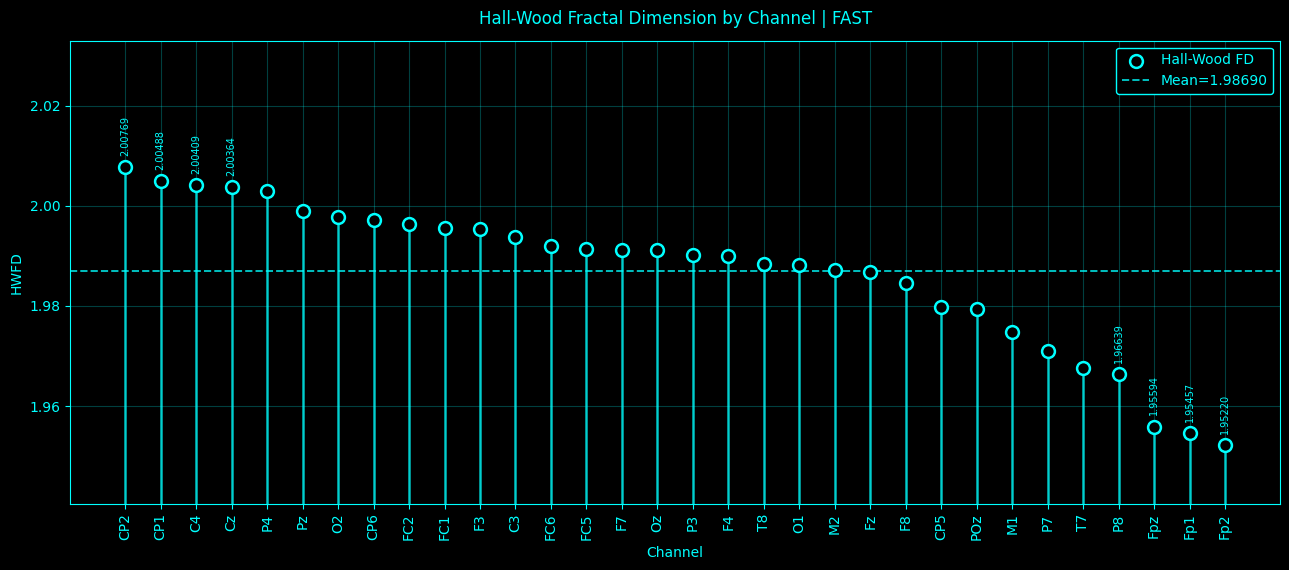

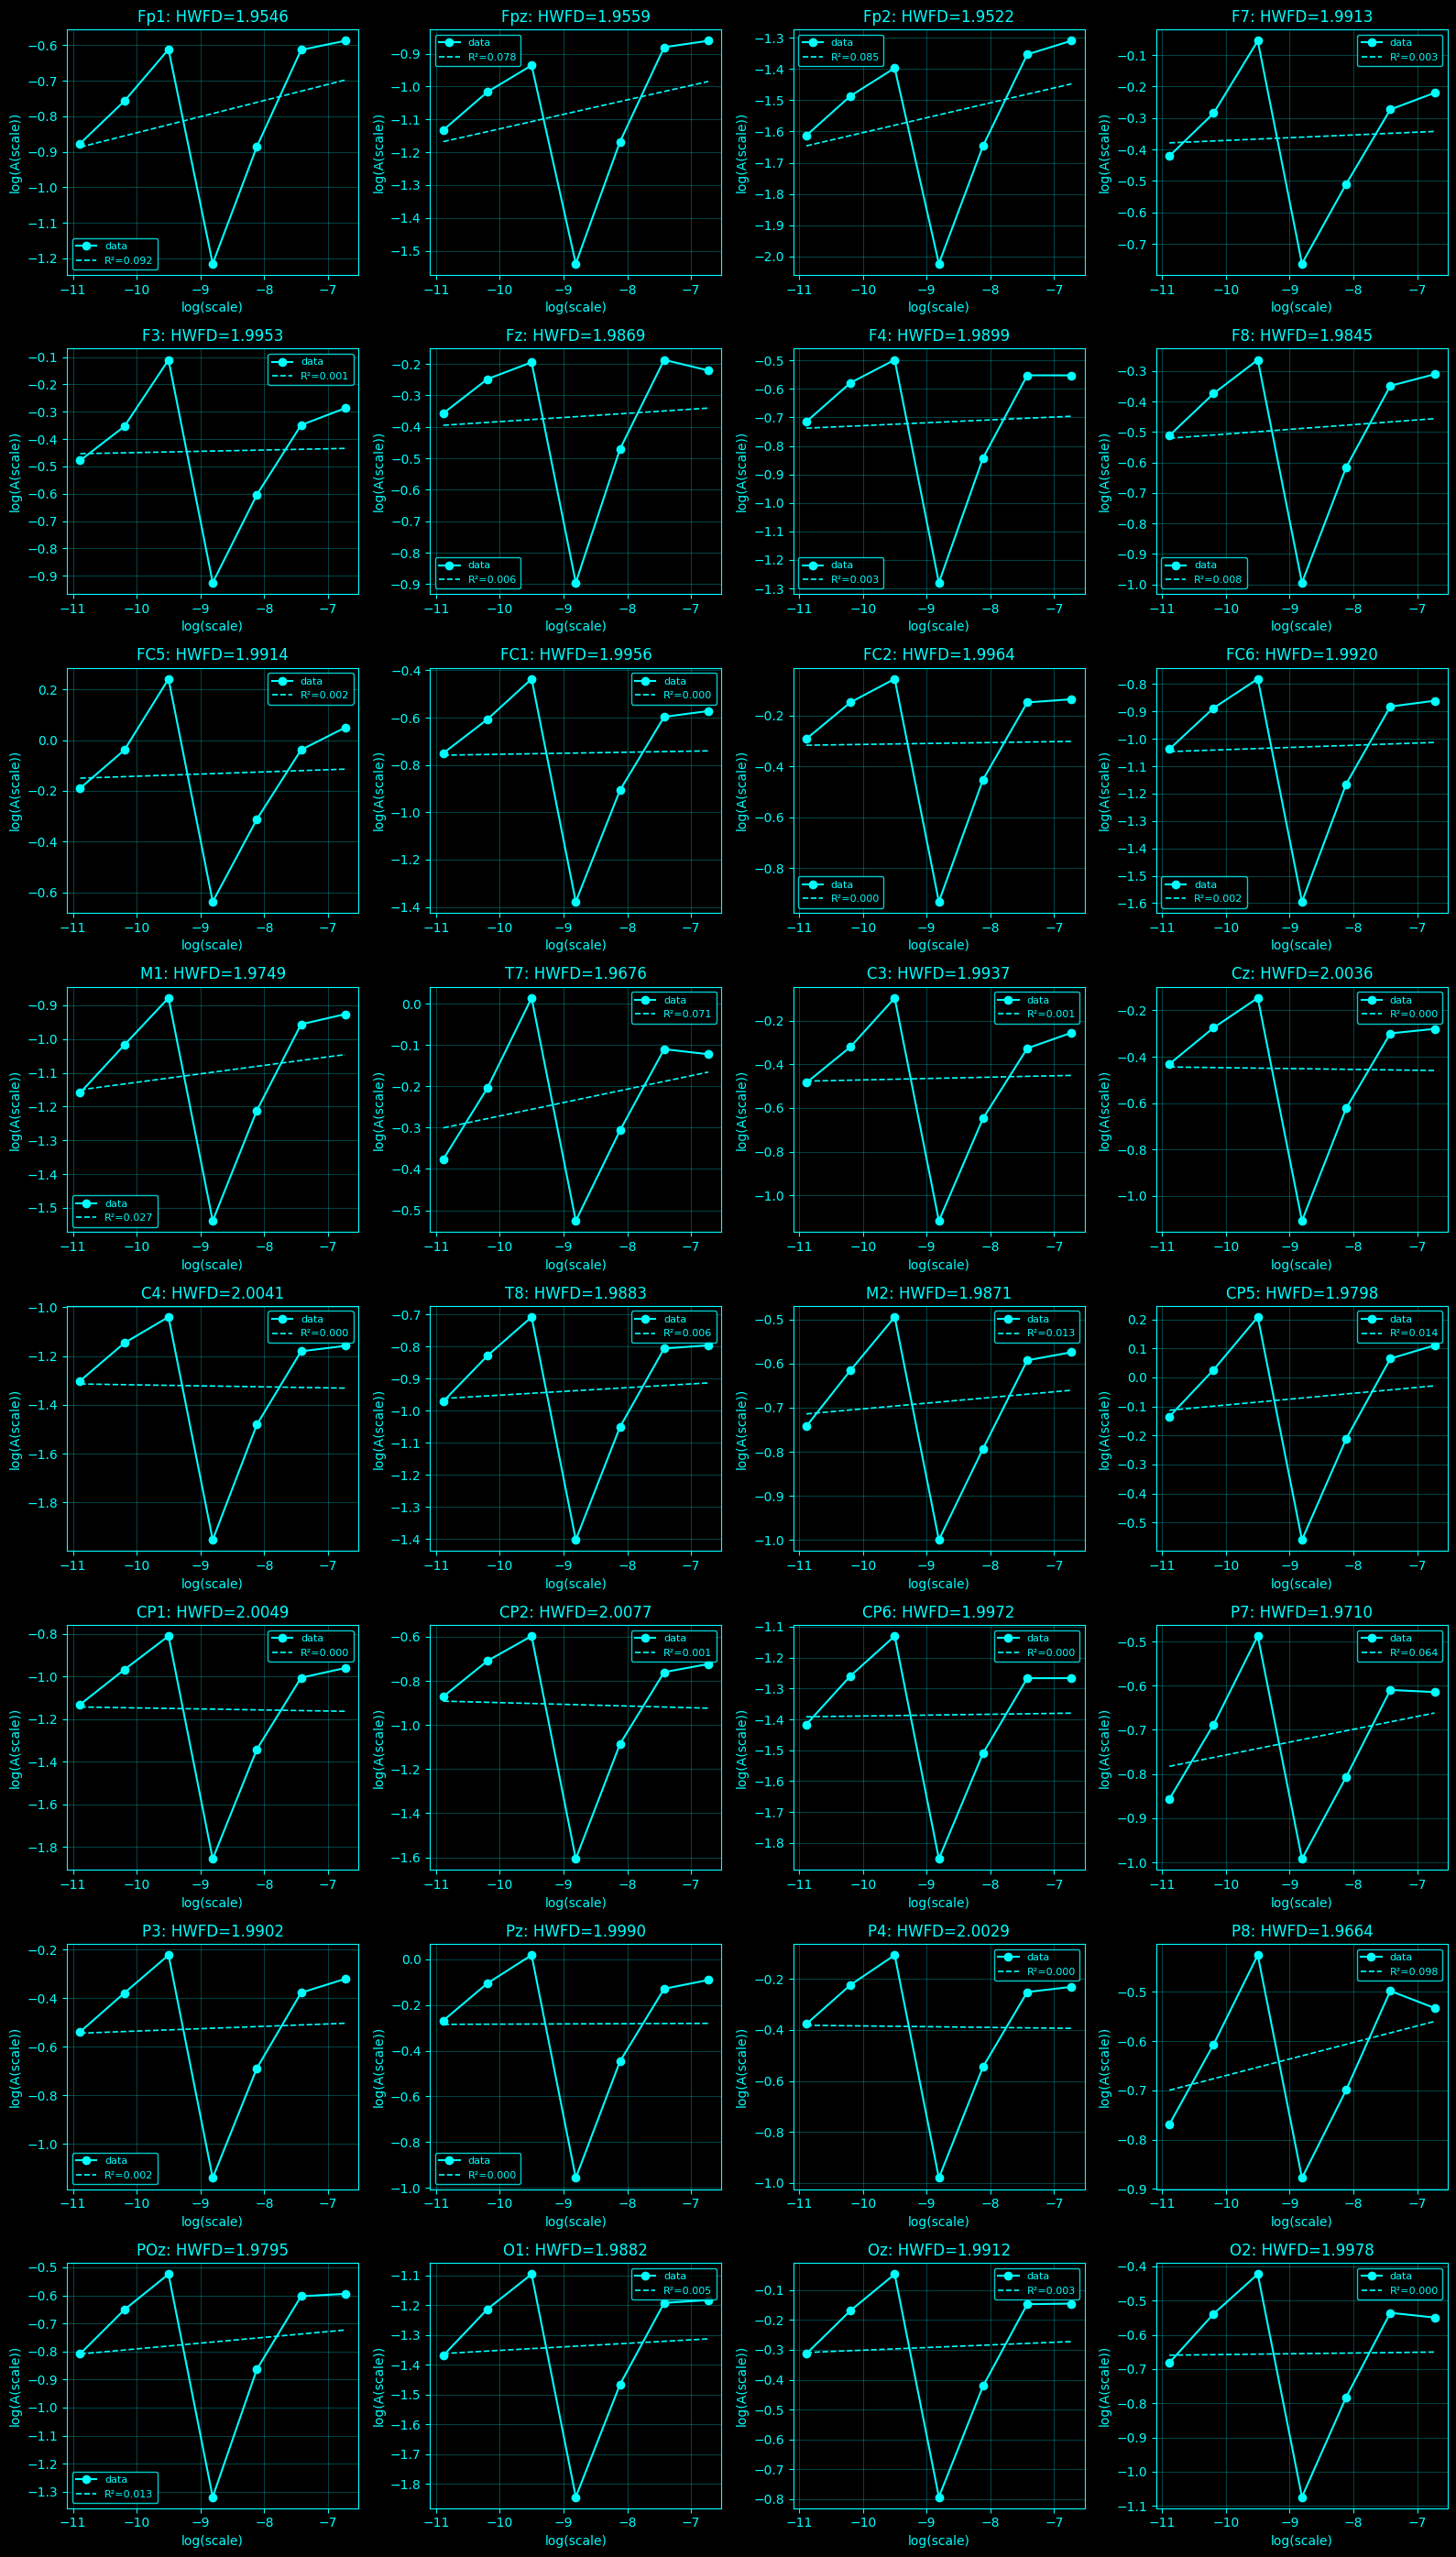

All-channel Hall-Wood fit plot saved to: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_hall_wood/all_channels_hall_wood_loglog_fits.png


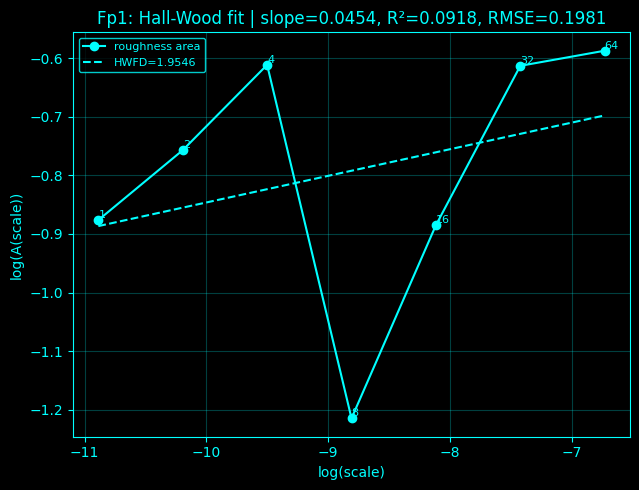

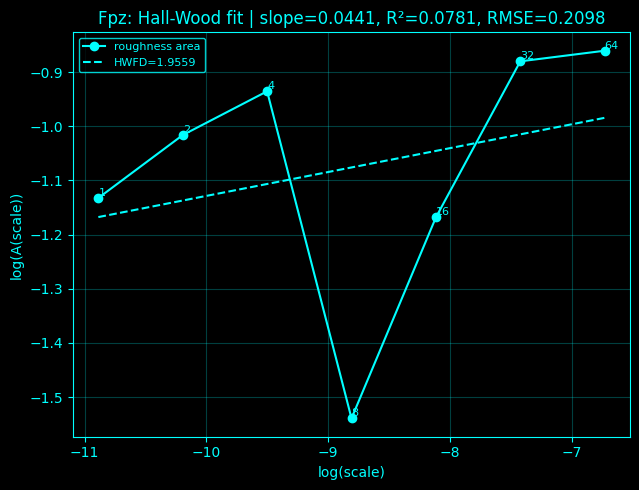

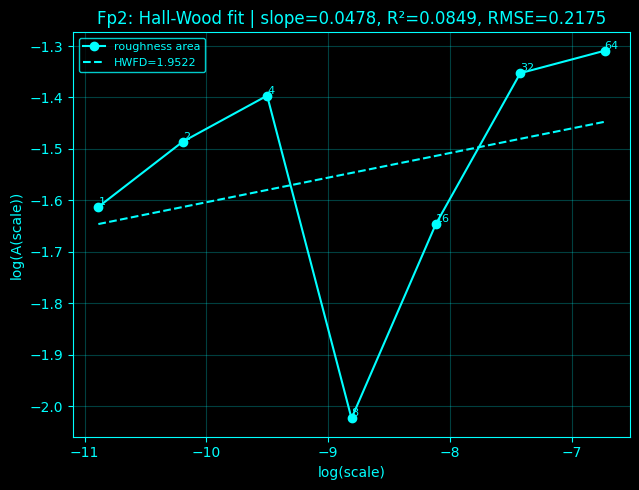

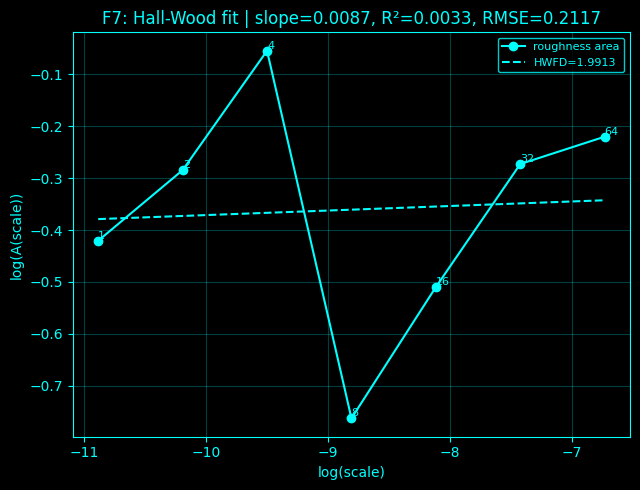

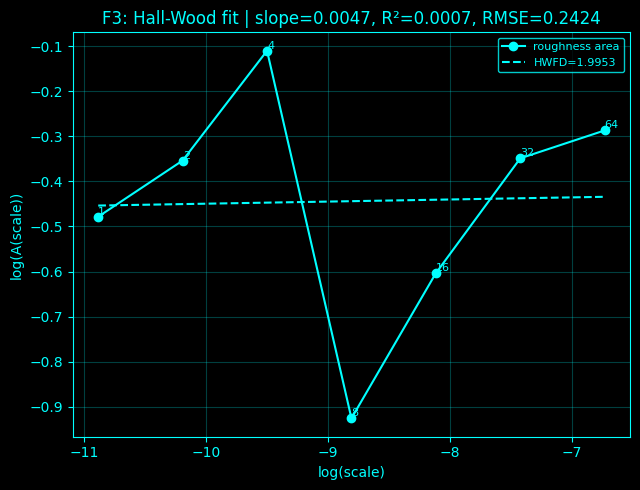

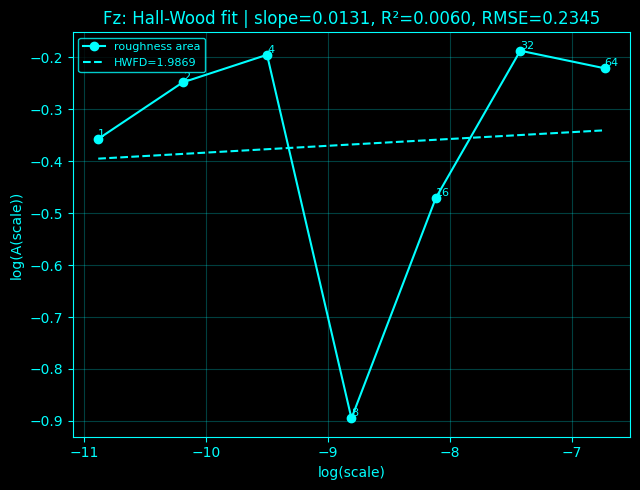

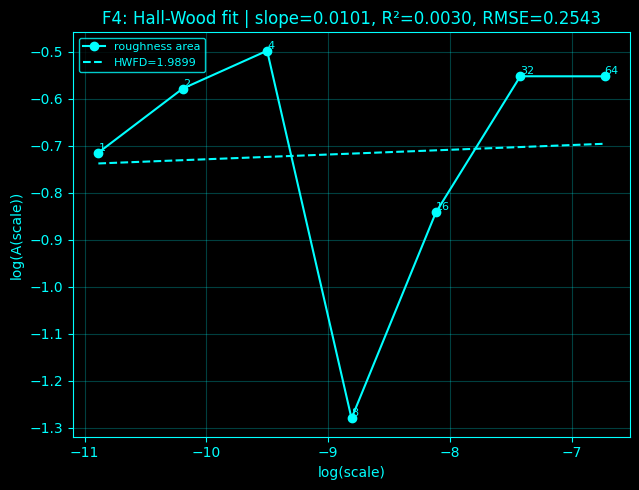

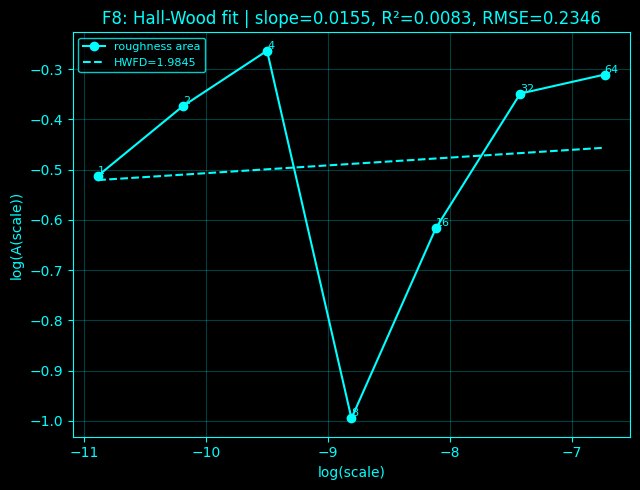

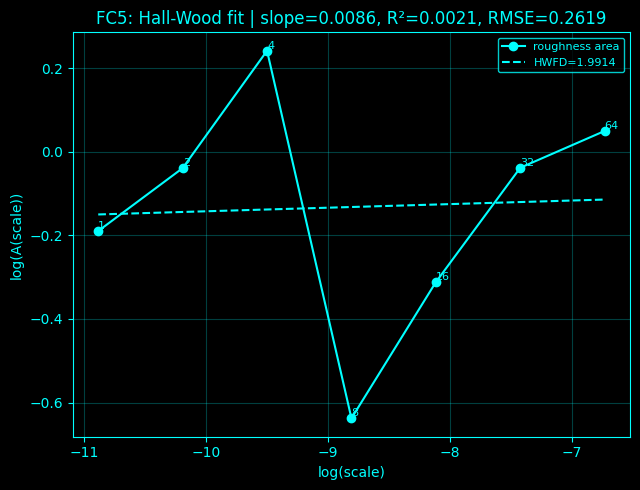

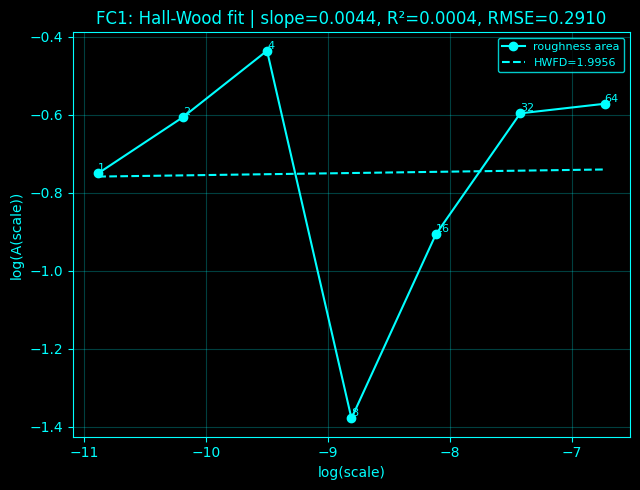

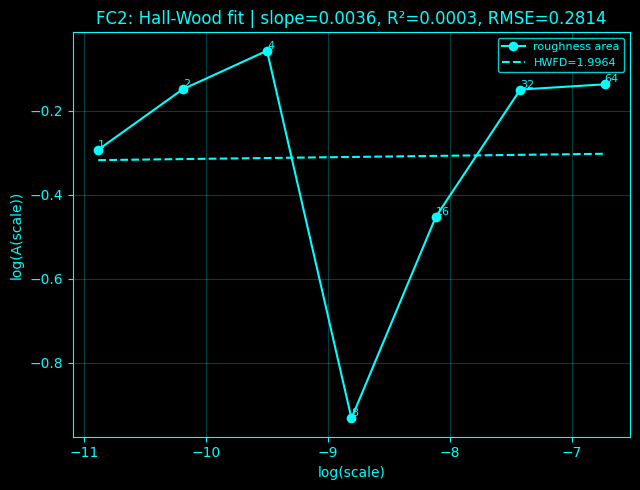

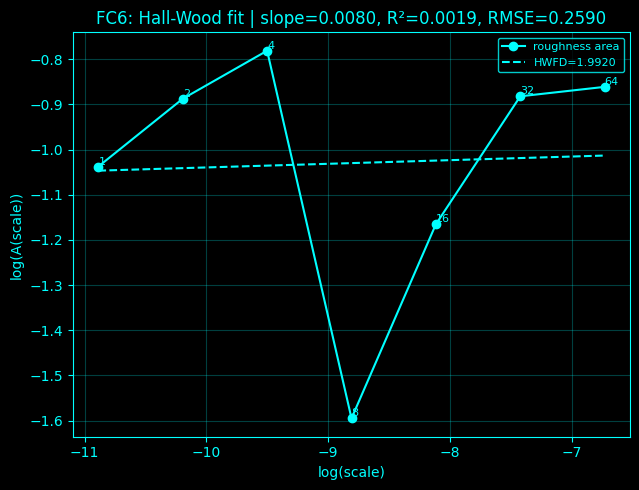

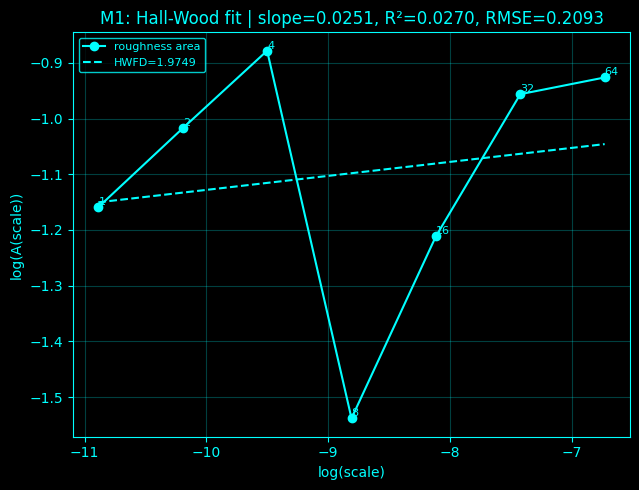

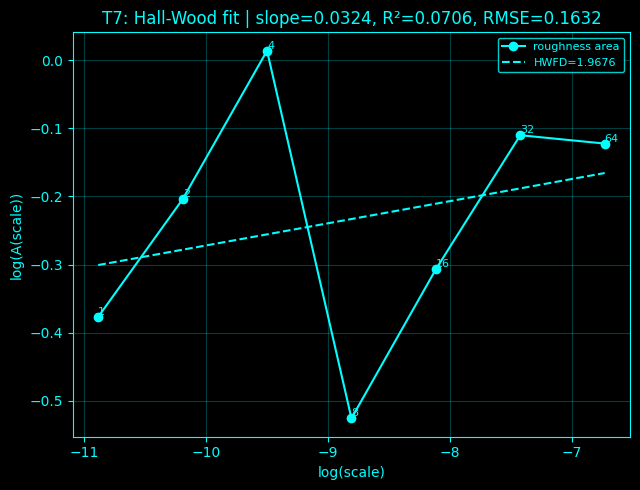

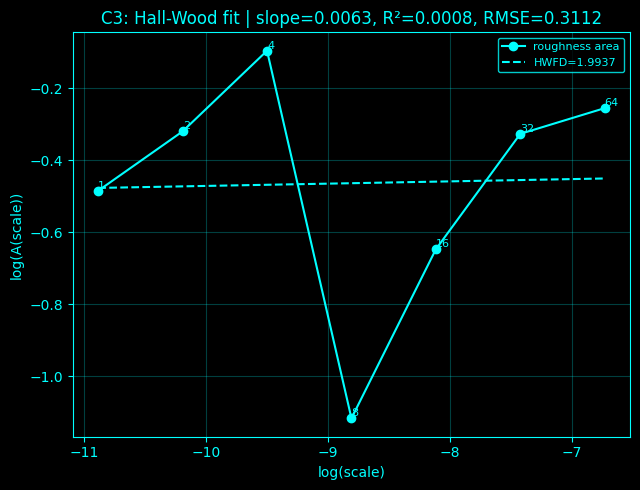

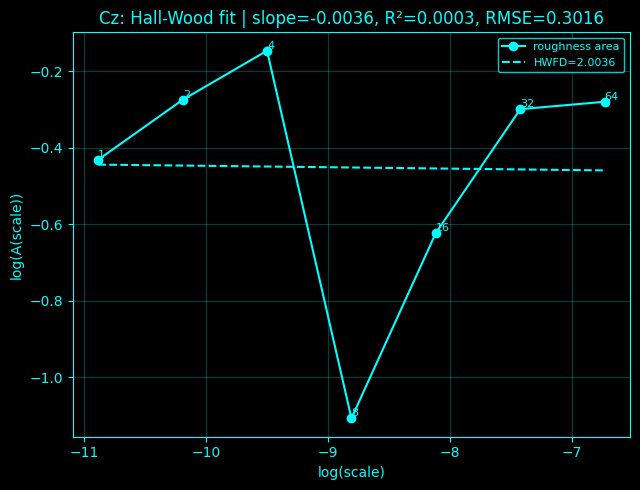

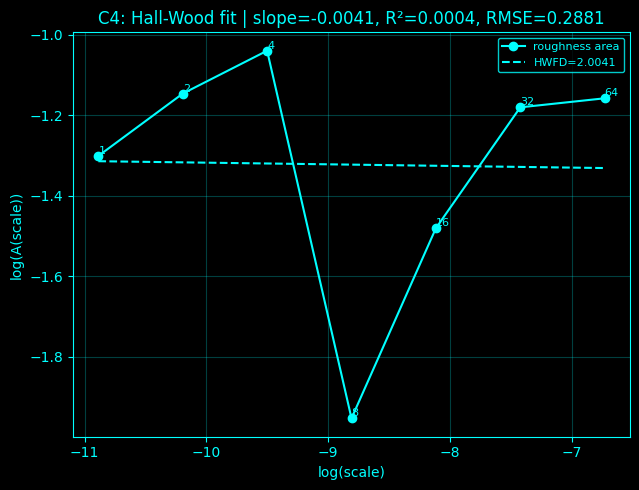

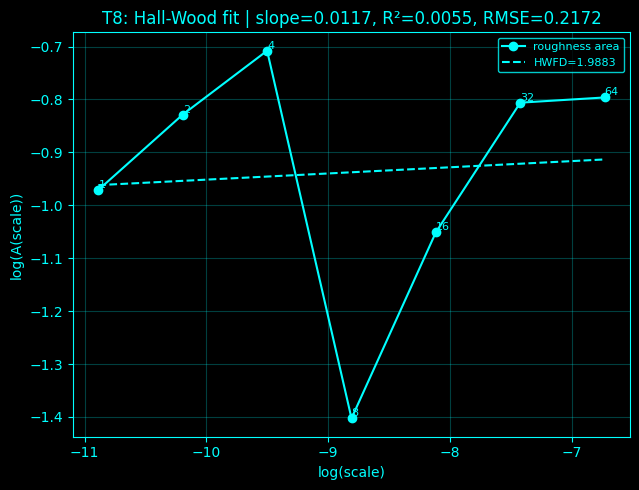

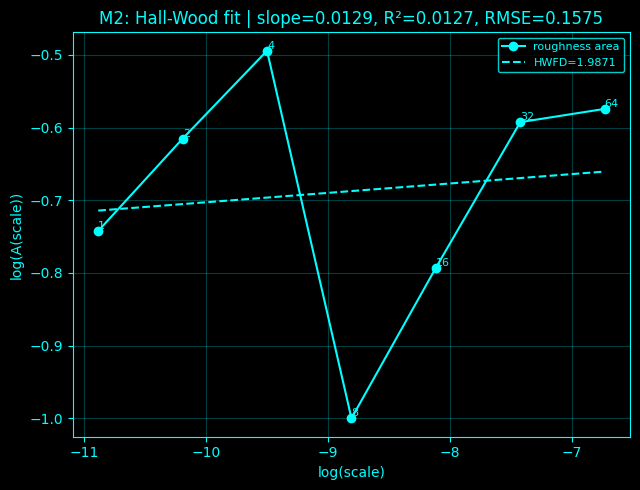

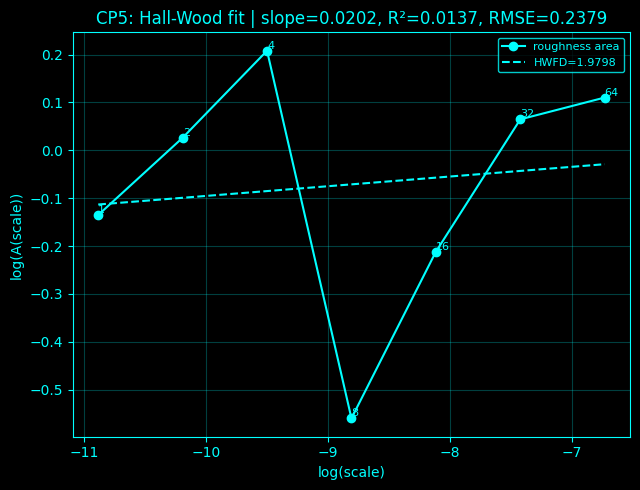

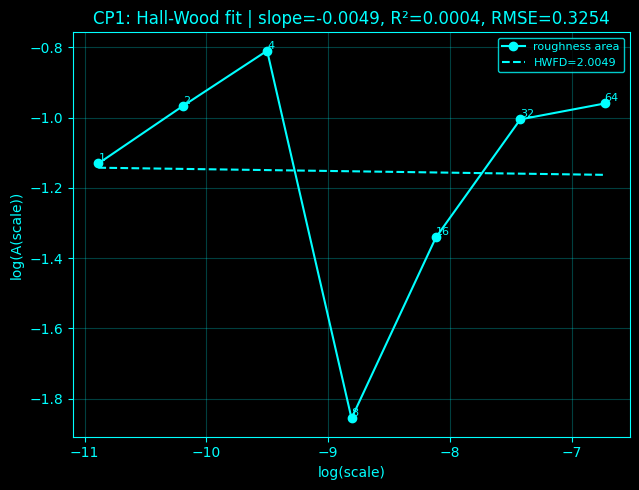

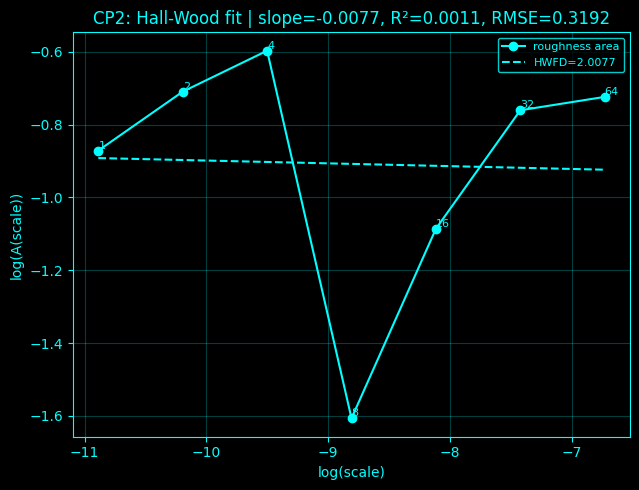

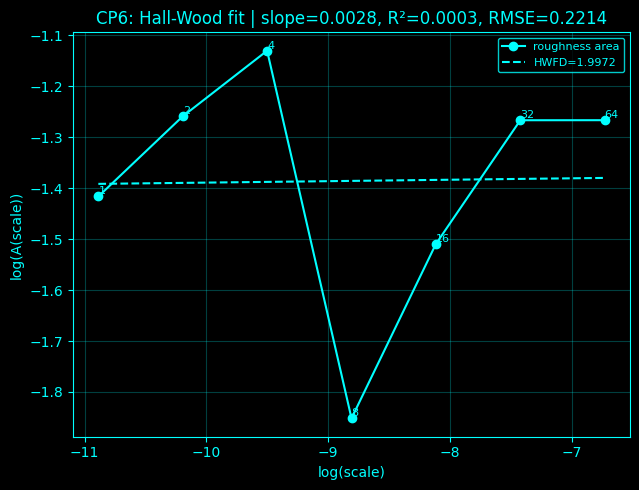

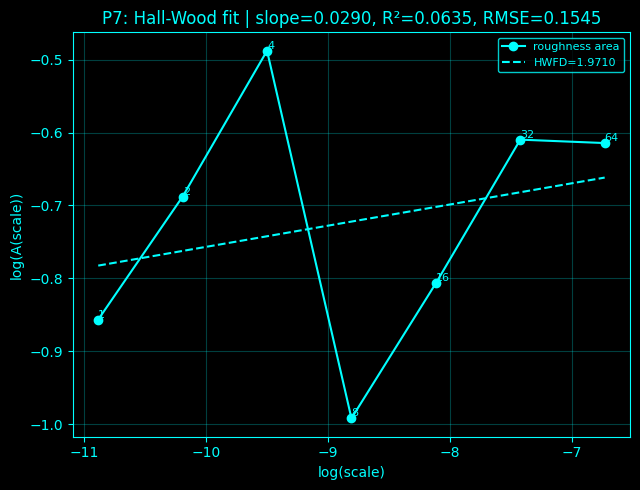

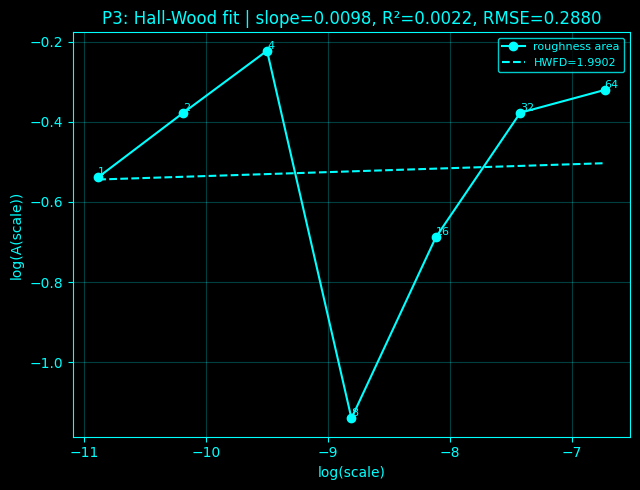

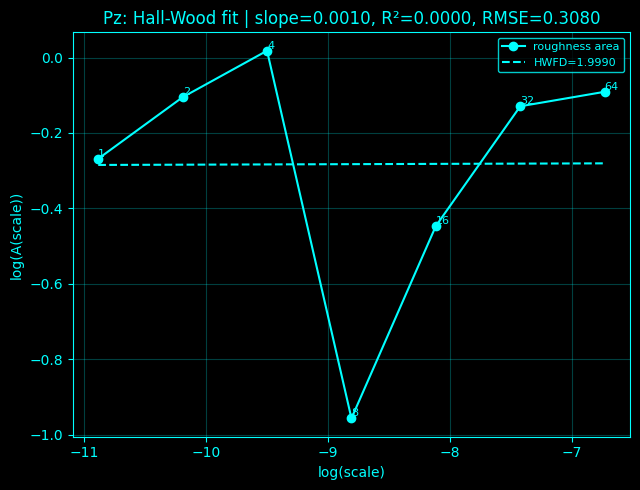

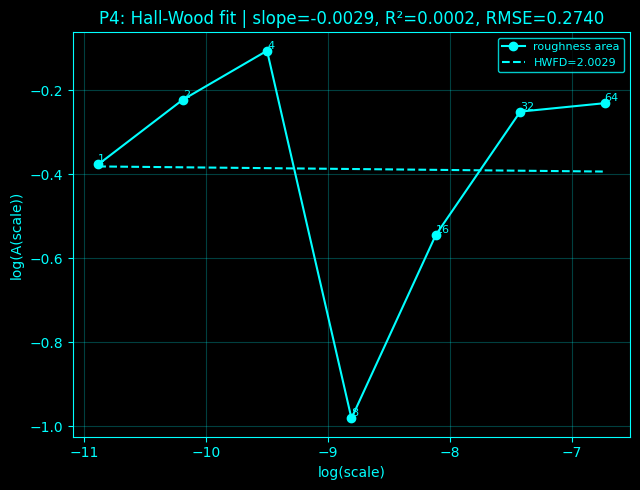

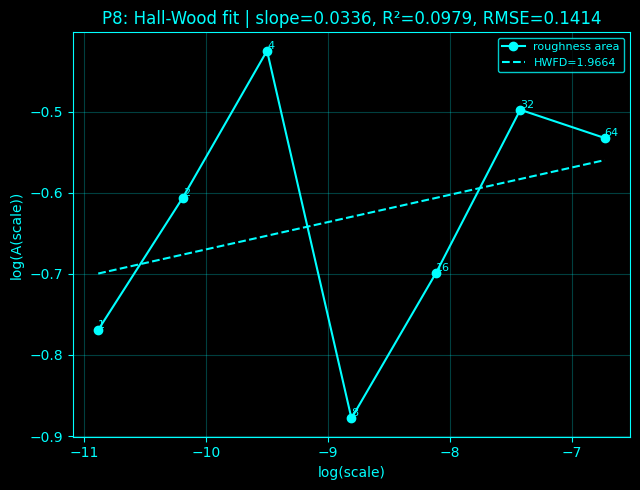

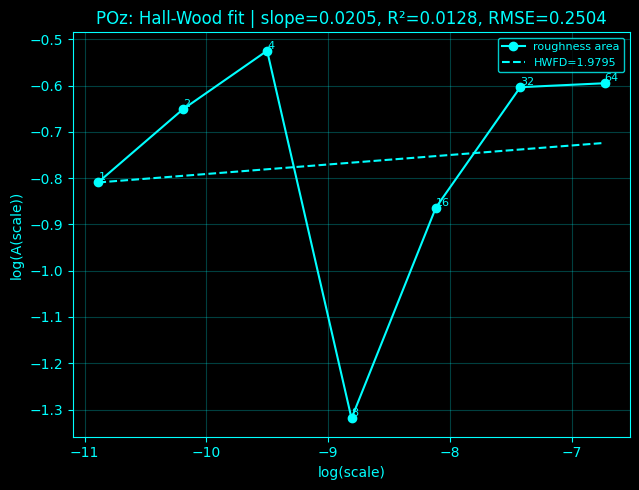

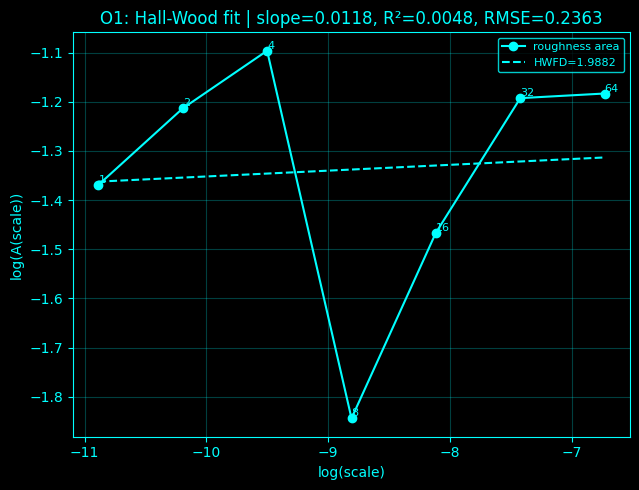

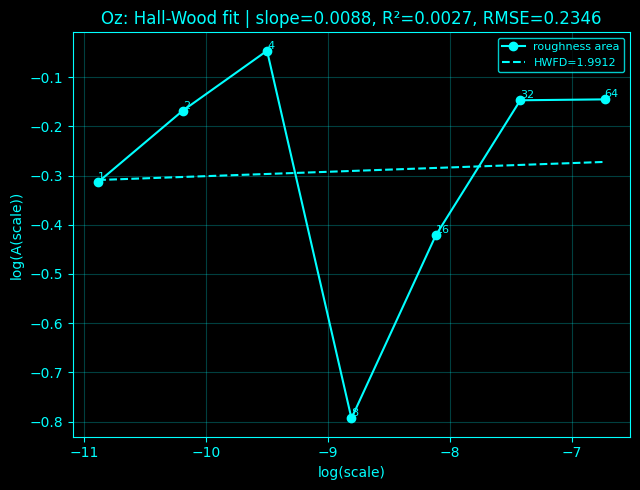

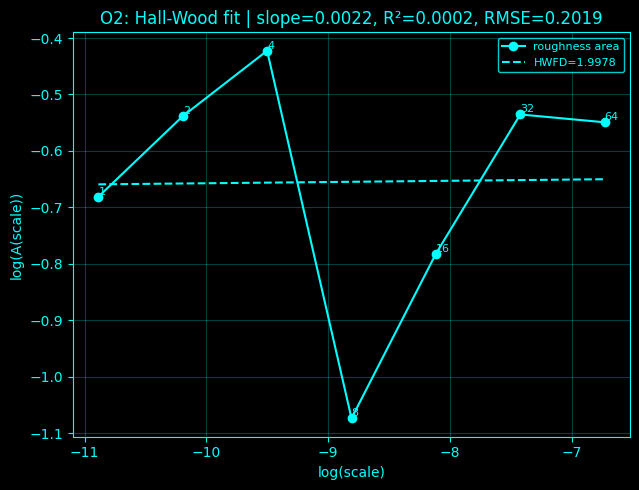

Per-channel Hall-Wood diagnostic plots saved to: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_hall_wood/per_channel_hall_wood_diagnostics


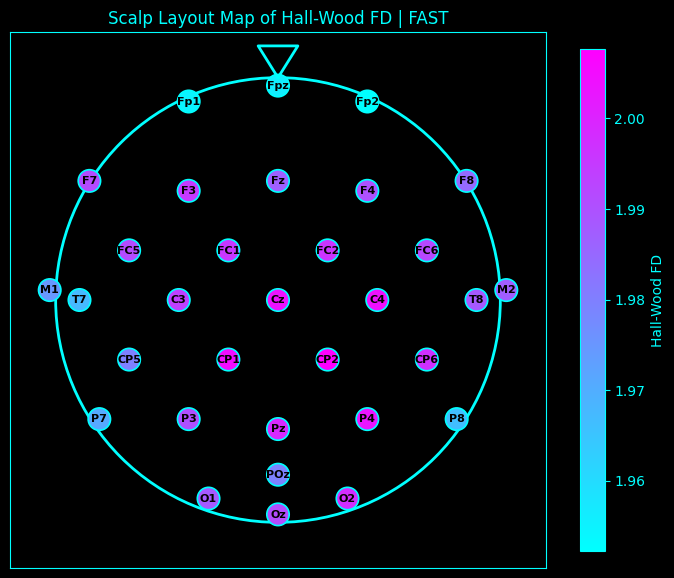

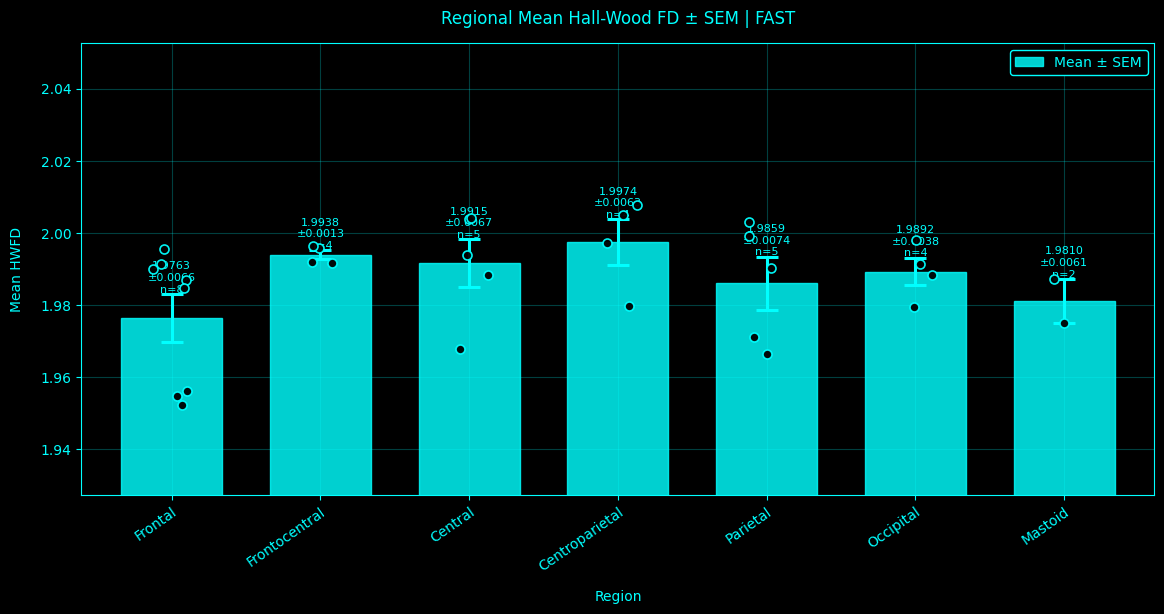

Regional summary plot saved to: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_hall_wood/expert_plots_fast/regional_hall_wood_fd_summary.png
Regional summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_hall_wood/expert_plots_fast/regional_hall_wood_fd_summary.csv
Regional channel-point CSV: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_hall_wood/expert_plots_fast/regional_hall_wood_fd_channel_points.csv


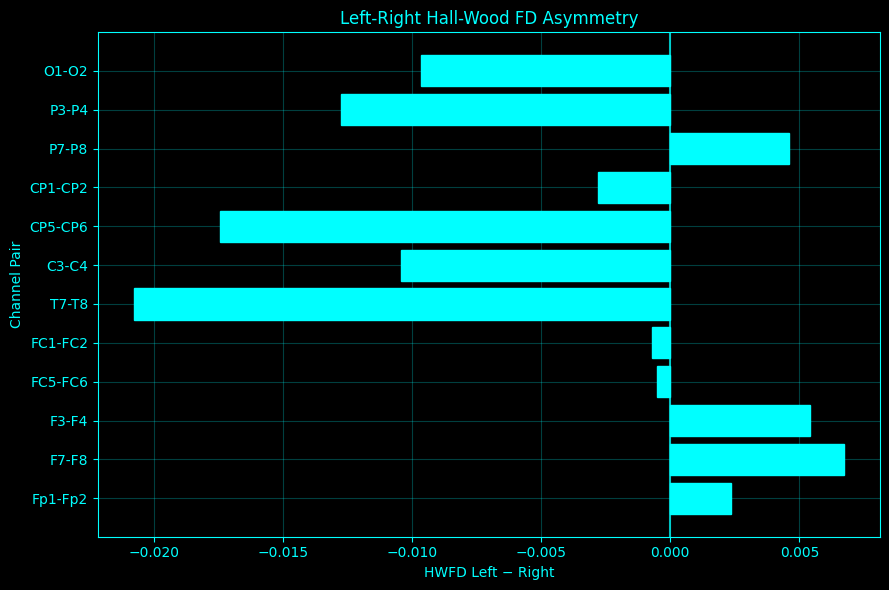

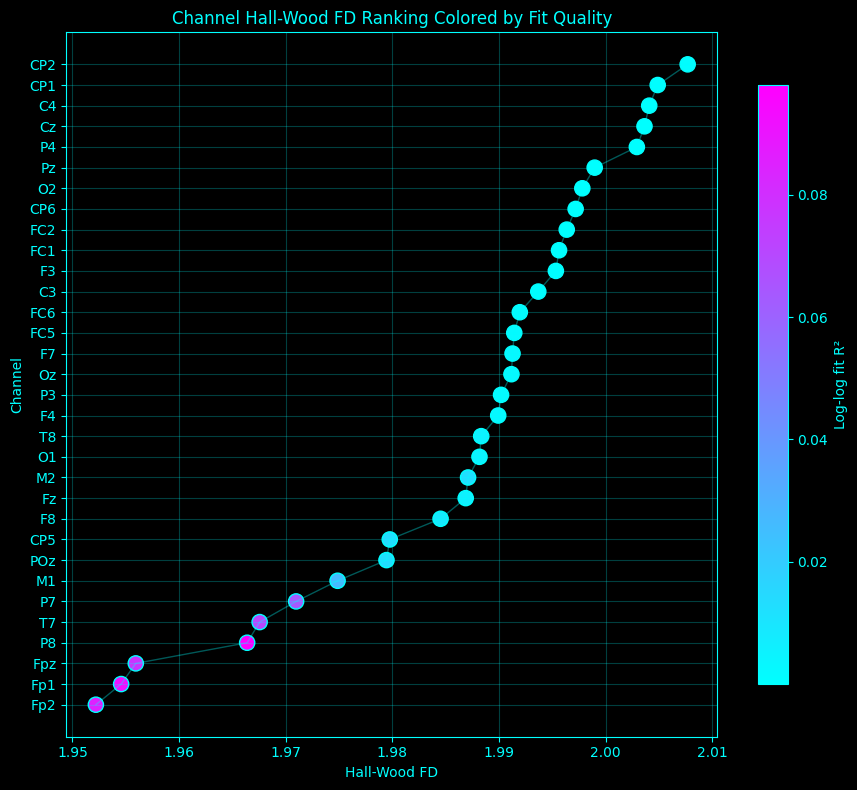

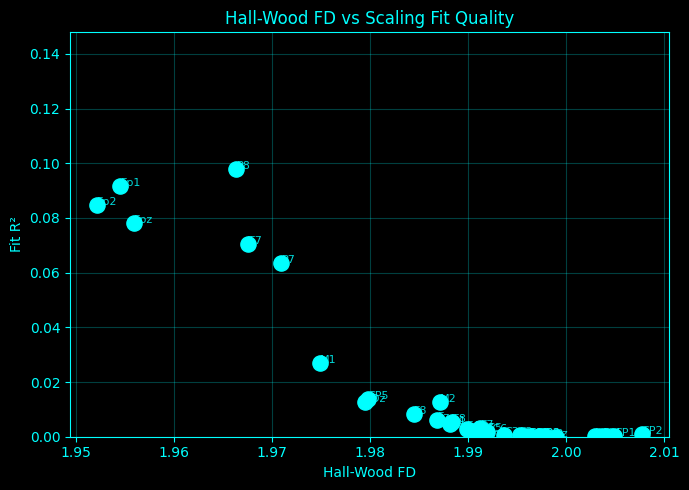

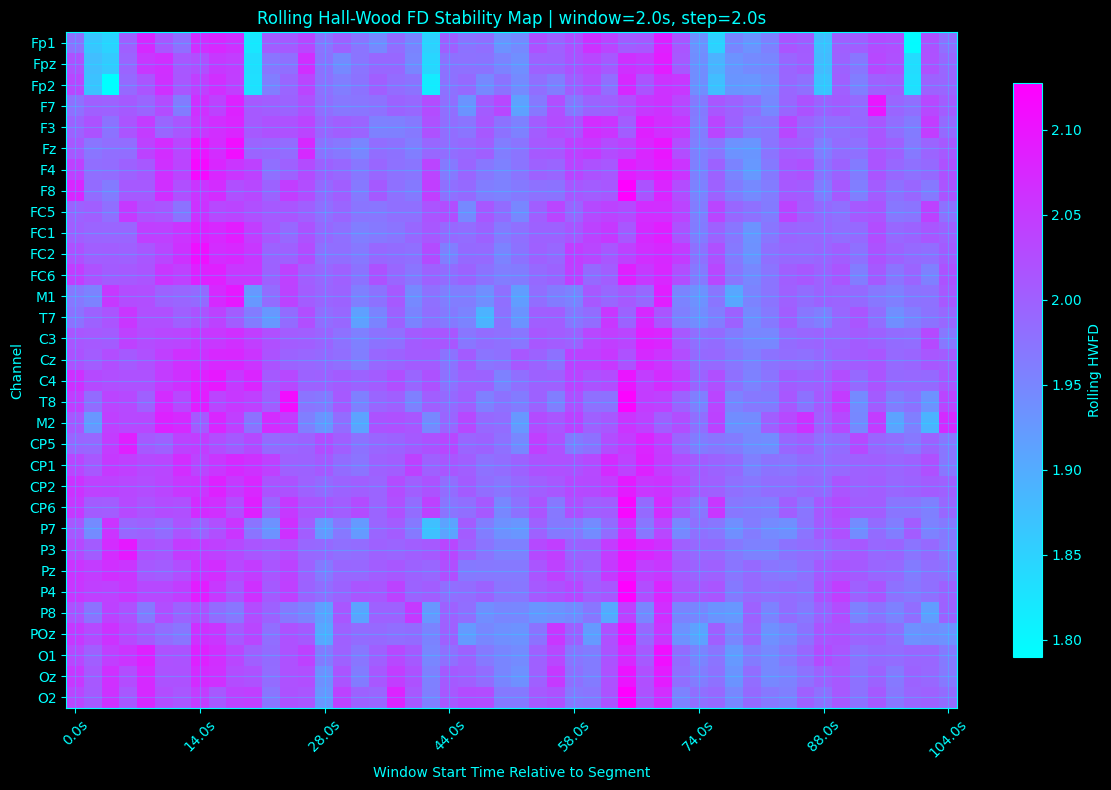

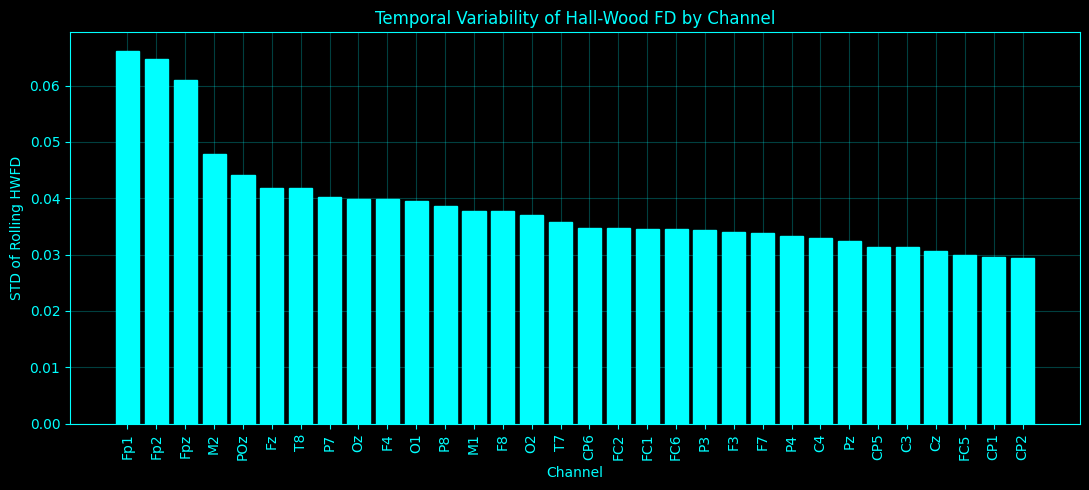

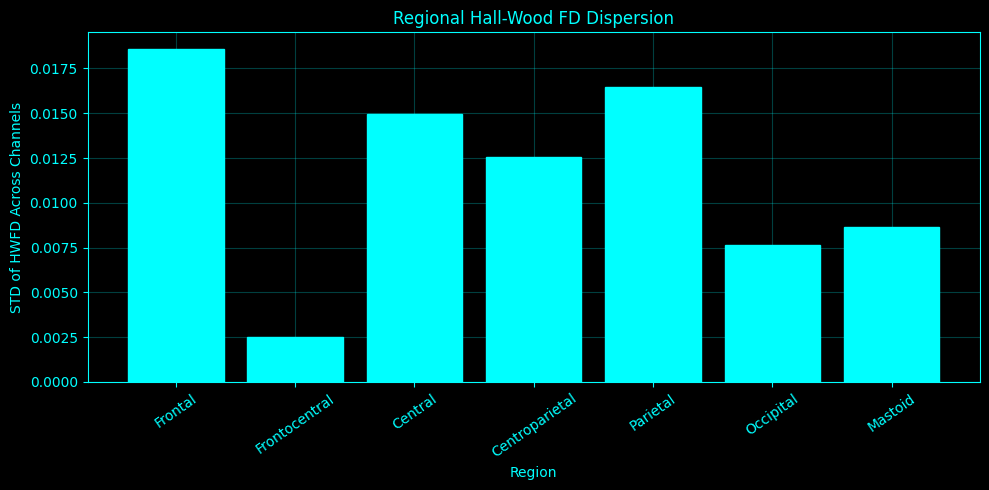

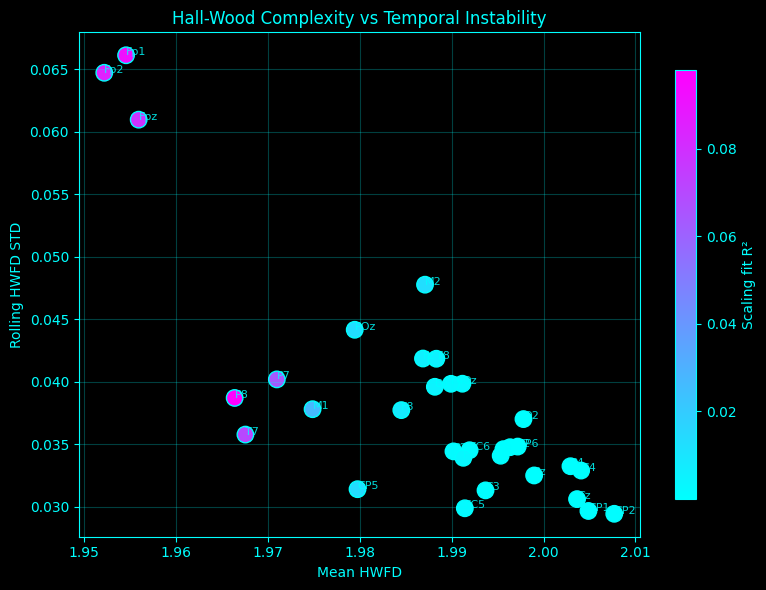


Expert plots saved to: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_hall_wood/expert_plots_fast
Regional summary: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_hall_wood/expert_plots_fast/regional_hall_wood_fd_summary.csv
Asymmetry CSV: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_hall_wood/expert_plots_fast/left_right_hall_wood_fd_asymmetry.csv
Rolling HWFD CSV: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_hall_wood/expert_plots_fast/rolling_hall_wood_fd_by_channel.csv
Rolling fit R² CSV: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_hall_wood/expert_plots_fast/rolling_hall_wood_fit_r2_by_channel.csv
Temporal variability CSV: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_hall_wood/expert_plots_fast/rolling_hall_wood_fd_temporal_variability.csv

Saved outputs to: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_hall_wood
Summary CSV: /home/

In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")
out_dir = os.path.join(base_dir, "fractal_dimension_hall_wood")
os.makedirs(out_dir, exist_ok=True)

# Same segment used in your recent analyses
sampling_rate = 1000
start_time, end_time = 814.571, 921.515
start_idx = int(start_time * sampling_rate)
end_idx   = int(end_time * sampling_rate)

eeg_channels = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

# -------------------------------------------------------
# SPEED MODE
# -------------------------------------------------------
# Options:
#   "normal"    = highest fidelity
#   "fast"      = faster, mild downsampling/truncation
#   "ultrafast" = fastest exploratory scan
MODE = "fast"

MODE_CONFIGS = {
    "normal": {
        "decimate": 1,
        "max_samples": None,
        "lags": [1, 2, 4, 8, 16, 32, 64, 128],
        "rolling_window_sec": 2.0,
        "rolling_step_sec": 1.0,
        "rolling_max_windows": 100,
        "expert_plots": True,
    },
    "fast": {
        "decimate": 2,
        "max_samples": 60000,
        "lags": [1, 2, 4, 8, 16, 32, 64],
        "rolling_window_sec": 2.0,
        "rolling_step_sec": 2.0,
        "rolling_max_windows": 50,
        "expert_plots": True,
    },
    "ultrafast": {
        "decimate": 5,
        "max_samples": 20000,
        "lags": [1, 2, 4, 8, 16, 32],
        "rolling_window_sec": 1.0,
        "rolling_step_sec": 3.0,
        "rolling_max_windows": 20,
        "expert_plots": True,
    },
}

if MODE not in MODE_CONFIGS:
    raise ValueError(f"Unknown MODE={MODE}. Use one of: {list(MODE_CONFIGS)}")

mode_cfg = MODE_CONFIGS[MODE]

decimate = mode_cfg["decimate"]
max_samples = mode_cfg["max_samples"]
hw_lags = mode_cfg["lags"]

ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

print(f"\nRunning Hall-Wood FD in {MODE.upper()} mode")
print(f"decimate={decimate}, max_samples={max_samples}, lags={hw_lags}")

# -------------------------------------------------------
# STYLE HELPER
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.grid(True, alpha=0.25, color=ACCENT)
    ax.tick_params(colors=ACCENT)

    for spine in ax.spines.values():
        spine.set_color(ACCENT)

# -------------------------------------------------------
# LOAD EEG
# -------------------------------------------------------
EEG_data = np.load(eeg_path, allow_pickle=True)

if EEG_data.ndim != 2:
    raise ValueError(f"Expected 2D EEG array, got shape {EEG_data.shape}")

# Handle either (time, channels) or (channels, time)
if EEG_data.shape[1] == len(eeg_channels):
    EEG_segment = EEG_data[start_idx:end_idx, :]
elif EEG_data.shape[0] == len(eeg_channels):
    EEG_segment = EEG_data[:, start_idx:end_idx].T
else:
    raise ValueError(f"Unexpected EEG shape: {EEG_data.shape}")

n_time, n_channels = EEG_segment.shape
print(f"Loaded EEG segment: {n_time} samples x {n_channels} channels")
print(f"Segment: [{start_time}, {end_time}] sec")

# -------------------------------------------------------
# APPLY SPEED MODE PREPROCESSING
# -------------------------------------------------------
effective_sampling_rate = sampling_rate

if decimate > 1:
    EEG_segment = EEG_segment[::decimate, :]
    effective_sampling_rate = sampling_rate / decimate

if max_samples is not None and EEG_segment.shape[0] > max_samples:
    EEG_segment = EEG_segment[:max_samples, :]

n_time, n_channels = EEG_segment.shape

print(f"After {MODE.upper()} mode preprocessing:")
print(f"  Segment shape: {n_time} samples x {n_channels} channels")
print(f"  Effective sampling rate: {effective_sampling_rate:.2f} Hz")
print(f"  Effective duration: {n_time / effective_sampling_rate:.2f} sec")

# -------------------------------------------------------
# HALL-WOOD FRACTAL DIMENSION
# -------------------------------------------------------
def hall_wood_fd(x, lags=None):
    """
    Compute Hall-Wood style fractal dimension for a 1D time series.

    For each lag l, estimate the scale-dependent curve roughness:

        A(l) = delta_l * sum_j |x[j+l] - x[j]|

    using non-overlapping lag-spaced increments, where:

        delta_l = l / (N - 1)

    Then fit:

        log A(l) ~ H * log delta_l

    and estimate graph fractal dimension as:

        D_HW = 2 - H

    Interpretation:
      - H is the roughness / scaling exponent.
      - Higher D_HW means rougher, more irregular waveform geometry.
      - This is a scalar time-series fractal-dimension analysis, not a phase-space method.
    """
    x = np.asarray(x, dtype=float)
    N = len(x)

    if lags is None:
        lags = [1, 2, 4, 8, 16, 32, 64]

    if N < 8:
        return np.nan, None, None, {
            "scaling_slope": np.nan,
            "fit_intercept": np.nan,
            "fit_r2": np.nan,
            "fit_rmse": np.nan,
            "n_valid_scales": 0,
            "mean_roughness_area": np.nan,
            "roughness_area_range": np.nan,
        }

    valid_lags = []
    deltas = []
    areas = []
    mean_abs_increments = []

    for lag in lags:
        lag = int(lag)

        if lag < 1:
            continue

        # Need at least a few non-overlapping increments.
        n_blocks = (N - 1) // lag

        if n_blocks < 3:
            continue

        idx0 = np.arange(0, n_blocks * lag, lag)
        idx1 = idx0 + lag

        idx1 = idx1[idx1 < N]
        idx0 = idx0[:len(idx1)]

        if len(idx0) < 3:
            continue

        diffs = np.abs(x[idx1] - x[idx0])
        delta = lag / max(N - 1, 1)

        area = delta * np.sum(diffs)

        if np.isfinite(area) and area > 0:
            valid_lags.append(lag)
            deltas.append(delta)
            areas.append(area)
            mean_abs_increments.append(np.mean(diffs))

    valid_lags = np.asarray(valid_lags, dtype=int)
    deltas = np.asarray(deltas, dtype=float)
    areas = np.asarray(areas, dtype=float)
    mean_abs_increments = np.asarray(mean_abs_increments, dtype=float)

    mask = np.isfinite(deltas) & np.isfinite(areas) & (deltas > 0) & (areas > 0)

    if np.sum(mask) < 2:
        return np.nan, valid_lags, areas, {
            "scaling_slope": np.nan,
            "fit_intercept": np.nan,
            "fit_r2": np.nan,
            "fit_rmse": np.nan,
            "n_valid_scales": int(np.sum(mask)),
            "mean_roughness_area": np.nanmean(areas) if len(areas) else np.nan,
            "roughness_area_range": (
                np.nanmax(areas) - np.nanmin(areas)
                if len(areas) else np.nan
            ),
        }

    log_delta = np.log(deltas[mask])
    log_area = np.log(areas[mask])

    slope, intercept = np.polyfit(log_delta, log_area, 1)
    pred = slope * log_delta + intercept

    resid = log_area - pred
    ss_res = np.sum(resid ** 2)
    ss_tot = np.sum((log_area - np.mean(log_area)) ** 2)

    r2 = 1.0 - ss_res / (ss_tot + 1e-12)
    rmse = np.sqrt(np.mean(resid ** 2))

    hwfd = 2.0 - slope

    return hwfd, valid_lags, areas, {
        "scaling_slope": slope,
        "fit_intercept": intercept,
        "fit_r2": r2,
        "fit_rmse": rmse,
        "n_valid_scales": int(np.sum(mask)),
        "mean_roughness_area": np.nanmean(areas),
        "roughness_area_range": np.nanmax(areas) - np.nanmin(areas),
        "deltas": deltas,
        "mean_abs_increments": mean_abs_increments,
    }

# -------------------------------------------------------
# RUN HALL-WOOD FD PER CHANNEL
# -------------------------------------------------------
rows = {}
curves = {}
diagnostic_rows = []

for ch_idx, ch_name in enumerate(eeg_channels):
    x = EEG_segment[:, ch_idx].astype(float)
    x = (x - np.mean(x)) / (np.std(x) + 1e-12)

    hwfd, lags_used, areas, diag = hall_wood_fd(x, lags=hw_lags)

    rows[ch_name] = {
        "channel": ch_name,
        "hall_wood_fd": hwfd,
        "scaling_slope": diag["scaling_slope"],
        "fit_intercept": diag["fit_intercept"],
        "fit_r2": diag["fit_r2"],
        "fit_rmse": diag["fit_rmse"],
        "n_valid_scales": diag["n_valid_scales"],
        "mean_roughness_area": diag["mean_roughness_area"],
        "roughness_area_range": diag["roughness_area_range"],
    }

    curves[ch_name] = {
        "lags": lags_used,
        "areas": areas,
        "deltas": diag.get("deltas", None),
        "mean_abs_increments": diag.get("mean_abs_increments", None),
    }

    diagnostic_rows.append(rows[ch_name])

results_df = (
    pd.DataFrame(diagnostic_rows)
    .sort_values("hall_wood_fd", ascending=False)
    .reset_index(drop=True)
)

csv_path = os.path.join(out_dir, "hall_wood_fd_summary.csv")
results_df.to_csv(csv_path, index=False)

print("\nHall-Wood Fractal Dimensions:")
print(results_df)

# -------------------------------------------------------
# SAVE DIAGNOSTIC TABLE
# -------------------------------------------------------
diagnostics_df = results_df.copy()

diagnostics_csv_path = os.path.join(out_dir, "hall_wood_fd_diagnostics.csv")
diagnostics_df.to_csv(diagnostics_csv_path, index=False)

print(f"\nDiagnostics CSV: {diagnostics_csv_path}")

# -------------------------------------------------------
# PLOT 1: FIXED HWFD BY CHANNEL PLOT
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(13, 5.8), facecolor=BG)
style_ax(ax)

plot_df = results_df.copy().sort_values("hall_wood_fd", ascending=False).reset_index(drop=True)

x_pos = np.arange(len(plot_df))
y = plot_df["hall_wood_fd"].to_numpy(dtype=float)

finite_y = y[np.isfinite(y)]

if len(finite_y) == 0:
    y_min, y_max, y_range = 0.0, 1.0, 1.0
else:
    y_min = np.nanmin(finite_y)
    y_max = np.nanmax(finite_y)
    y_range = y_max - y_min

if not np.isfinite(y_range) or y_range <= 0:
    y_range = 0.001

pad = max(0.0005, y_range * 0.35)
baseline = y_min - pad * 0.6

ax.vlines(
    x_pos,
    baseline,
    y,
    color=ACCENT,
    linewidth=1.8,
    alpha=0.75
)

ax.scatter(
    x_pos,
    y,
    s=85,
    facecolors=BG,
    edgecolors=ACCENT,
    linewidths=1.8,
    zorder=4,
    label="Hall-Wood FD"
)

mean_hwfd = np.nanmean(y)

ax.axhline(
    mean_hwfd,
    color=ACCENT,
    linestyle="--",
    linewidth=1.4,
    alpha=0.75,
    label=f"Mean={mean_hwfd:.5f}"
)

top_n = min(4, len(plot_df))
label_indices = list(range(top_n)) + list(range(len(plot_df) - top_n, len(plot_df)))

for i in sorted(set(label_indices)):
    if np.isfinite(y[i]):
        ax.text(
            x_pos[i],
            y[i] + pad * 0.12,
            f"{y[i]:.5f}",
            ha="center",
            va="bottom",
            fontsize=7,
            color=ACCENT,
            rotation=90
        )

ax.set_ylim(baseline, y_max + pad * 1.3)

ax.set_title(f"Hall-Wood Fractal Dimension by Channel | {MODE.upper()}", pad=12)
ax.set_xlabel("Channel")
ax.set_ylabel("HWFD")

ax.set_xticks(x_pos)
ax.set_xticklabels(plot_df["channel"], rotation=90)

ax.legend(loc="best", framealpha=1.0)

bar_path = os.path.join(out_dir, "hall_wood_fd_barplot.png")
plt.tight_layout()
plt.savefig(bar_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 2: ALL-CHANNEL HALL-WOOD LOG-LOG FITS
# -------------------------------------------------------
n_cols = 4
n_rows = int(np.ceil(len(eeg_channels) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4 * n_cols, 3.5 * n_rows),
    facecolor=BG
)

axes = axes.flatten()

for ax_idx, ch_name in enumerate(eeg_channels):
    ax = axes[ax_idx]
    style_ax(ax)

    d = curves[ch_name]
    lags_used = d["lags"]
    areas = d["areas"]
    deltas = d["deltas"]

    hwfd_val = rows[ch_name]["hall_wood_fd"]
    slope = rows[ch_name]["scaling_slope"]
    intercept = rows[ch_name]["fit_intercept"]
    r2 = rows[ch_name]["fit_r2"]

    if lags_used is None or areas is None or deltas is None:
        ax.set_title(f"{ch_name}: no data")
        ax.axis("off")
        continue

    mask = np.isfinite(deltas) & np.isfinite(areas) & (deltas > 0) & (areas > 0)

    if np.sum(mask) < 2:
        ax.set_title(f"{ch_name}: insufficient data")
        ax.axis("off")
        continue

    log_delta = np.log(deltas[mask])
    log_area = np.log(areas[mask])
    fit_line = slope * log_delta + intercept

    ax.plot(
        log_delta,
        log_area,
        marker="o",
        color=ACCENT,
        markerfacecolor=ACCENT,
        markeredgecolor=ACCENT,
        linewidth=1.5,
        label="data"
    )

    ax.plot(
        log_delta,
        fit_line,
        color=ACCENT,
        linestyle="--",
        linewidth=1.2,
        label=f"R²={r2:.3f}"
    )

    ax.set_title(f"{ch_name}: HWFD={hwfd_val:.4f}")
    ax.set_xlabel("log(scale)")
    ax.set_ylabel("log(A(scale))")
    ax.legend(fontsize=8)

for j in range(len(eeg_channels), len(axes)):
    axes[j].axis("off")

all_fits_path = os.path.join(out_dir, "all_channels_hall_wood_loglog_fits.png")
plt.tight_layout()
plt.savefig(all_fits_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

print(f"All-channel Hall-Wood fit plot saved to: {all_fits_path}")

# -------------------------------------------------------
# OPTIONAL: SAVE ONE DIAGNOSTIC PLOT PER CHANNEL
# -------------------------------------------------------
per_channel_dir = os.path.join(out_dir, "per_channel_hall_wood_diagnostics")
os.makedirs(per_channel_dir, exist_ok=True)

for ch_name in eeg_channels:
    d = curves[ch_name]
    lags_used = d["lags"]
    areas = d["areas"]
    deltas = d["deltas"]

    hwfd_val = rows[ch_name]["hall_wood_fd"]
    slope = rows[ch_name]["scaling_slope"]
    intercept = rows[ch_name]["fit_intercept"]
    r2 = rows[ch_name]["fit_r2"]
    rmse = rows[ch_name]["fit_rmse"]

    if lags_used is None or areas is None or deltas is None:
        continue

    mask = np.isfinite(deltas) & np.isfinite(areas) & (deltas > 0) & (areas > 0)

    if np.sum(mask) < 2:
        continue

    log_delta = np.log(deltas[mask])
    log_area = np.log(areas[mask])
    fit_line = slope * log_delta + intercept

    fig, ax = plt.subplots(figsize=(6.5, 5), facecolor=BG)
    style_ax(ax)

    ax.plot(
        log_delta,
        log_area,
        marker="o",
        color=ACCENT,
        markerfacecolor=ACCENT,
        markeredgecolor=ACCENT,
        label="roughness area"
    )

    ax.plot(
        log_delta,
        fit_line,
        color=ACCENT,
        linestyle="--",
        label=f"HWFD={hwfd_val:.4f}"
    )

    for xd, yd, lag in zip(log_delta, log_area, np.asarray(lags_used)[mask]):
        ax.text(
            xd,
            yd,
            f"{lag}",
            fontsize=8,
            color=ACCENT,
            ha="left",
            va="bottom"
        )

    ax.set_title(
        f"{ch_name}: Hall-Wood fit | slope={slope:.4f}, R²={r2:.4f}, RMSE={rmse:.4f}"
    )

    ax.set_xlabel("log(scale)")
    ax.set_ylabel("log(A(scale))")
    ax.legend(fontsize=8)

    diag_path = os.path.join(per_channel_dir, f"{ch_name}_hall_wood_diagnostic.png")
    plt.tight_layout()
    plt.savefig(diag_path, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close()

print(f"Per-channel Hall-Wood diagnostic plots saved to: {per_channel_dir}")

# -------------------------------------------------------
# SAVE ALL CURVES
# -------------------------------------------------------
npz_path = os.path.join(out_dir, "hall_wood_fd_curves.npz")

save_dict = {
    "channels": np.asarray(eeg_channels),
    "hall_wood_fd": np.asarray([rows[ch]["hall_wood_fd"] for ch in eeg_channels], dtype=float),
    "scaling_slope": np.asarray([rows[ch]["scaling_slope"] for ch in eeg_channels], dtype=float),
    "fit_r2": np.asarray([rows[ch]["fit_r2"] for ch in eeg_channels], dtype=float),
    "fit_rmse": np.asarray([rows[ch]["fit_rmse"] for ch in eeg_channels], dtype=float),
}

for ch_name, d in curves.items():
    if d["lags"] is not None:
        save_dict[f"{ch_name}_lags"] = d["lags"]
    if d["deltas"] is not None:
        save_dict[f"{ch_name}_deltas"] = d["deltas"]
    if d["areas"] is not None:
        save_dict[f"{ch_name}_roughness_area"] = d["areas"]
    if d["mean_abs_increments"] is not None:
        save_dict[f"{ch_name}_mean_abs_increments"] = d["mean_abs_increments"]

np.savez(npz_path, **save_dict)

# -------------------------------------------------------
# EXPERT-LEVEL ADDITIONAL PLOTS
# -------------------------------------------------------
if mode_cfg["expert_plots"]:

    expert_dir = os.path.join(out_dir, f"expert_plots_{MODE}")
    os.makedirs(expert_dir, exist_ok=True)

    hwfd_map = dict(zip(results_df["channel"], results_df["hall_wood_fd"]))
    slope_map = dict(zip(results_df["channel"], results_df["scaling_slope"]))
    r2_map = dict(zip(results_df["channel"], results_df["fit_r2"]))
    area_map = dict(zip(results_df["channel"], results_df["mean_roughness_area"]))

    # ---------------------------------------------------
    # PLOT 3: SCALP-LAYOUT HWFD MAP
    # ---------------------------------------------------
    scalp_xy = {
        "Fp1": (-0.45, 1.00), "Fpz": (0.00, 1.08), "Fp2": (0.45, 1.00),
        "F7": (-0.95, 0.60), "F3": (-0.45, 0.55), "Fz": (0.00, 0.60),
        "F4": (0.45, 0.55), "F8": (0.95, 0.60),

        "FC5": (-0.75, 0.25), "FC1": (-0.25, 0.25),
        "FC2": (0.25, 0.25), "FC6": (0.75, 0.25),

        "M1": (-1.15, 0.05), "T7": (-1.00, 0.00), "C3": (-0.50, 0.00),
        "Cz": (0.00, 0.00), "C4": (0.50, 0.00), "T8": (1.00, 0.00),
        "M2": (1.15, 0.05),

        "CP5": (-0.75, -0.30), "CP1": (-0.25, -0.30),
        "CP2": (0.25, -0.30), "CP6": (0.75, -0.30),

        "P7": (-0.90, -0.60), "P3": (-0.45, -0.60), "Pz": (0.00, -0.65),
        "P4": (0.45, -0.60), "P8": (0.90, -0.60),

        "POz": (0.00, -0.88),
        "O1": (-0.35, -1.00), "Oz": (0.00, -1.08), "O2": (0.35, -1.00),
    }

    xs, ys, vals, labels = [], [], [], []

    for ch in eeg_channels:
        if ch in scalp_xy and ch in hwfd_map and np.isfinite(hwfd_map[ch]):
            xs.append(scalp_xy[ch][0])
            ys.append(scalp_xy[ch][1])
            vals.append(hwfd_map[ch])
            labels.append(ch)

    fig, ax = plt.subplots(figsize=(7, 7), facecolor=BG)
    style_ax(ax)

    head = plt.Circle((0, 0), 1.12, fill=False, color=ACCENT, linewidth=2)
    ax.add_patch(head)

    nose_x = [0.00, -0.10, 0.10, 0.00]
    nose_y = [1.12, 1.28, 1.28, 1.12]
    ax.plot(nose_x, nose_y, color=ACCENT, linewidth=2)

    sc = ax.scatter(
        xs,
        ys,
        c=vals,
        s=260,
        cmap="cool",
        edgecolor=ACCENT,
        linewidth=1.2
    )

    for x0, y0, label in zip(xs, ys, labels):
        ax.text(
            x0,
            y0,
            label,
            ha="center",
            va="center",
            fontsize=8,
            color=BG,
            fontweight="bold"
        )

    cbar = plt.colorbar(sc, ax=ax, shrink=0.75)
    cbar.set_label("Hall-Wood FD", color=ACCENT)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)

    ax.set_title(f"Scalp Layout Map of Hall-Wood FD | {MODE.upper()}")
    ax.set_xlim(-1.35, 1.35)
    ax.set_ylim(-1.35, 1.35)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])

    scalp_path = os.path.join(expert_dir, "hall_wood_fd_scalp_layout_map.png")
    plt.tight_layout()
    plt.savefig(scalp_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

    # ---------------------------------------------------
    # PLOT 4: REGIONAL HWFD SUMMARY
    # ---------------------------------------------------
    regions = {
        "Frontal": ["Fp1", "Fpz", "Fp2", "F7", "F3", "Fz", "F4", "F8"],
        "Frontocentral": ["FC5", "FC1", "FC2", "FC6"],
        "Central": ["T7", "C3", "Cz", "C4", "T8"],
        "Centroparietal": ["CP5", "CP1", "CP2", "CP6"],
        "Parietal": ["P7", "P3", "Pz", "P4", "P8"],
        "Occipital": ["POz", "O1", "Oz", "O2"],
        "Mastoid": ["M1", "M2"],
    }

    region_rows = []
    region_points = []

    for region_name, chans in regions.items():
        vals_region = []

        for ch in chans:
            if ch in hwfd_map and np.isfinite(hwfd_map[ch]):
                vals_region.append(hwfd_map[ch])
                region_points.append({
                    "region": region_name,
                    "channel": ch,
                    "hwfd": hwfd_map[ch],
                })

        if len(vals_region) == 0:
            continue

        vals_region = np.asarray(vals_region, dtype=float)

        region_rows.append({
            "region": region_name,
            "mean_hwfd": np.mean(vals_region),
            "std_hwfd": np.std(vals_region, ddof=1) if len(vals_region) > 1 else 0.0,
            "sem_hwfd": (
                np.std(vals_region, ddof=1) / np.sqrt(len(vals_region))
                if len(vals_region) > 1 else 0.0
            ),
            "n_channels": len(vals_region),
        })

    region_df = pd.DataFrame(region_rows)
    region_points_df = pd.DataFrame(region_points)

    region_csv_path = os.path.join(expert_dir, "regional_hall_wood_fd_summary.csv")
    region_df.to_csv(region_csv_path, index=False)

    region_points_csv_path = os.path.join(expert_dir, "regional_hall_wood_fd_channel_points.csv")
    region_points_df.to_csv(region_points_csv_path, index=False)

    fig, ax = plt.subplots(figsize=(12, 6.5), facecolor=BG)
    style_ax(ax)

    x_region = np.arange(len(region_df))

    ax.bar(
        x_region,
        region_df["mean_hwfd"],
        yerr=region_df["sem_hwfd"],
        color=ACCENT,
        edgecolor=ACCENT,
        alpha=0.82,
        width=0.68,
        capsize=8,
        error_kw={
            "elinewidth": 2.2,
            "capthick": 2.2,
            "ecolor": ACCENT,
            "alpha": 1.0,
        },
        label="Mean ± SEM"
    )

    rng = np.random.default_rng(7)

    for i, region_name in enumerate(region_df["region"]):
        vals = region_points_df.loc[
            region_points_df["region"] == region_name,
            "hwfd"
        ].to_numpy(dtype=float)

        if len(vals) == 0:
            continue

        jitter = rng.uniform(-0.13, 0.13, size=len(vals))

        ax.scatter(
            np.full(len(vals), i) + jitter,
            vals,
            s=42,
            facecolors=BG,
            edgecolors=ACCENT,
            linewidths=1.2,
            alpha=0.95,
            zorder=4
        )

    for i, row in region_df.iterrows():
        y_val = row["mean_hwfd"]
        sem = row["sem_hwfd"]

        ax.text(
            i,
            y_val + sem,
            f"{y_val:.4f}\n±{sem:.4f}\nn={int(row['n_channels'])}",
            ha="center",
            va="bottom",
            fontsize=8,
            color=ACCENT
        )

    all_region_vals = region_points_df["hwfd"].to_numpy(dtype=float)
    all_sem_upper = region_df["mean_hwfd"].to_numpy(dtype=float) + region_df["sem_hwfd"].to_numpy(dtype=float)
    all_sem_lower = region_df["mean_hwfd"].to_numpy(dtype=float) - region_df["sem_hwfd"].to_numpy(dtype=float)

    y_min = np.nanmin(np.concatenate([all_region_vals, all_sem_lower]))
    y_max = np.nanmax(np.concatenate([all_region_vals, all_sem_upper]))

    y_range = y_max - y_min
    if not np.isfinite(y_range) or y_range <= 0:
        y_range = 0.01

    pad = max(0.0025, y_range * 0.45)

    ax.set_ylim(y_min - pad, y_max + pad * 1.8)

    ax.set_title(f"Regional Mean Hall-Wood FD ± SEM | {MODE.upper()}", pad=14)
    ax.set_xlabel("Region", labelpad=12)
    ax.set_ylabel("Mean HWFD", labelpad=12)

    ax.set_xticks(x_region)
    ax.set_xticklabels(
        region_df["region"],
        rotation=35,
        ha="right",
        rotation_mode="anchor"
    )

    ax.margins(x=0.04)
    ax.legend(loc="best", framealpha=1.0)

    region_path = os.path.join(expert_dir, "regional_hall_wood_fd_summary.png")
    plt.tight_layout(pad=2.0)
    plt.savefig(region_path, dpi=220, bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"Regional summary plot saved to: {region_path}")
    print(f"Regional summary CSV: {region_csv_path}")
    print(f"Regional channel-point CSV: {region_points_csv_path}")

    # ---------------------------------------------------
    # PLOT 5: LEFT-RIGHT ASYMMETRY
    # ---------------------------------------------------
    lr_pairs = [
        ("Fp1", "Fp2"),
        ("F7", "F8"),
        ("F3", "F4"),
        ("FC5", "FC6"),
        ("FC1", "FC2"),
        ("T7", "T8"),
        ("C3", "C4"),
        ("CP5", "CP6"),
        ("CP1", "CP2"),
        ("P7", "P8"),
        ("P3", "P4"),
        ("O1", "O2"),
    ]

    asym_rows = []

    for left_ch, right_ch in lr_pairs:
        if left_ch in hwfd_map and right_ch in hwfd_map:
            left_val = hwfd_map[left_ch]
            right_val = hwfd_map[right_ch]

            if np.isfinite(left_val) and np.isfinite(right_val):
                asym_rows.append({
                    "pair": f"{left_ch}-{right_ch}",
                    "left_channel": left_ch,
                    "right_channel": right_ch,
                    "left_hwfd": left_val,
                    "right_hwfd": right_val,
                    "asymmetry_left_minus_right": left_val - right_val,
                })

    asym_df = pd.DataFrame(asym_rows)
    asym_csv_path = os.path.join(expert_dir, "left_right_hall_wood_fd_asymmetry.csv")
    asym_df.to_csv(asym_csv_path, index=False)

    fig, ax = plt.subplots(figsize=(9, 6), facecolor=BG)
    style_ax(ax)

    ax.axvline(0, color=ACCENT, linewidth=1.5, alpha=0.75)

    ax.barh(
        asym_df["pair"],
        asym_df["asymmetry_left_minus_right"],
        color=ACCENT,
        edgecolor=ACCENT
    )

    ax.set_title("Left-Right Hall-Wood FD Asymmetry")
    ax.set_xlabel("HWFD Left − Right")
    ax.set_ylabel("Channel Pair")

    asym_path = os.path.join(expert_dir, "left_right_hall_wood_fd_asymmetry.png")
    plt.tight_layout()
    plt.savefig(asym_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

    # ---------------------------------------------------
    # PLOT 6: HWFD RANKING COLORED BY FIT QUALITY
    # ---------------------------------------------------
    rank_df = diagnostics_df.copy()
    rank_df = rank_df.sort_values("hall_wood_fd", ascending=True).reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(9, 8), facecolor=BG)
    style_ax(ax)

    sc = ax.scatter(
        rank_df["hall_wood_fd"],
        rank_df["channel"],
        c=rank_df["fit_r2"],
        s=120,
        cmap="cool",
        edgecolor=ACCENT,
        linewidth=1.0
    )

    ax.plot(
        rank_df["hall_wood_fd"],
        rank_df["channel"],
        color=ACCENT,
        alpha=0.35,
        linewidth=1.0
    )

    cbar = plt.colorbar(sc, ax=ax, shrink=0.85)
    cbar.set_label("Log-log fit R²", color=ACCENT)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)

    ax.set_title("Channel Hall-Wood FD Ranking Colored by Fit Quality")
    ax.set_xlabel("Hall-Wood FD")
    ax.set_ylabel("Channel")

    ranking_path = os.path.join(expert_dir, "hall_wood_fd_ranking_fit_quality.png")
    plt.tight_layout()
    plt.savefig(ranking_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

    # ---------------------------------------------------
    # PLOT 7: HWFD VS FIT R²
    # ---------------------------------------------------
    fig, ax = plt.subplots(figsize=(7, 5), facecolor=BG)
    style_ax(ax)

    ax.scatter(
        diagnostics_df["hall_wood_fd"],
        diagnostics_df["fit_r2"],
        s=120,
        color=ACCENT,
        edgecolor=ACCENT
    )

    for _, row in diagnostics_df.iterrows():
        if np.isfinite(row["hall_wood_fd"]) and np.isfinite(row["fit_r2"]):
            ax.text(
                row["hall_wood_fd"],
                row["fit_r2"],
                row["channel"],
                fontsize=8,
                color=ACCENT,
                alpha=0.85
            )

    ax.set_title("Hall-Wood FD vs Scaling Fit Quality")
    ax.set_xlabel("Hall-Wood FD")
    ax.set_ylabel("Fit R²")

    r2_min = np.nanmin(diagnostics_df["fit_r2"])
    r2_max = np.nanmax(diagnostics_df["fit_r2"])

    if np.isfinite(r2_min) and np.isfinite(r2_max):
        ax.set_ylim(
            max(0, r2_min - 0.05),
            min(1.01, r2_max + 0.05)
        )

    quality_path = os.path.join(expert_dir, "hall_wood_fd_vs_fit_r2.png")
    plt.tight_layout()
    plt.savefig(quality_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

    # ---------------------------------------------------
    # PLOT 8: TEMPORAL STABILITY HEATMAP
    # ---------------------------------------------------
    rolling_window_samples = int(mode_cfg["rolling_window_sec"] * effective_sampling_rate)
    rolling_step_samples = int(mode_cfg["rolling_step_sec"] * effective_sampling_rate)

    rolling_window_samples = max(rolling_window_samples, 128)
    rolling_step_samples = max(rolling_step_samples, 1)

    possible_starts = np.arange(
        0,
        max(1, n_time - rolling_window_samples + 1),
        rolling_step_samples
    )

    if len(possible_starts) > mode_cfg["rolling_max_windows"]:
        chosen_idx = np.linspace(
            0,
            len(possible_starts) - 1,
            mode_cfg["rolling_max_windows"]
        ).astype(int)

        possible_starts = possible_starts[chosen_idx]

    rolling_hwfd = np.full((len(eeg_channels), len(possible_starts)), np.nan)
    rolling_r2 = np.full((len(eeg_channels), len(possible_starts)), np.nan)

    for w_idx, s0 in enumerate(possible_starts):
        s1 = s0 + rolling_window_samples

        for ch_idx, ch_name in enumerate(eeg_channels):
            xw = EEG_segment[s0:s1, ch_idx].astype(float)
            xw = (xw - np.mean(xw)) / (np.std(xw) + 1e-12)

            hwfd_w, _, _, diag_w = hall_wood_fd(xw, lags=hw_lags)
            rolling_hwfd[ch_idx, w_idx] = hwfd_w
            rolling_r2[ch_idx, w_idx] = diag_w["fit_r2"]

    rolling_times = possible_starts / effective_sampling_rate

    rolling_df = pd.DataFrame(
        rolling_hwfd,
        index=eeg_channels,
        columns=[f"{t:.3f}s" for t in rolling_times]
    )

    rolling_csv_path = os.path.join(expert_dir, "rolling_hall_wood_fd_by_channel.csv")
    rolling_df.to_csv(rolling_csv_path)

    rolling_r2_df = pd.DataFrame(
        rolling_r2,
        index=eeg_channels,
        columns=[f"{t:.3f}s" for t in rolling_times]
    )

    rolling_r2_csv_path = os.path.join(expert_dir, "rolling_hall_wood_fit_r2_by_channel.csv")
    rolling_r2_df.to_csv(rolling_r2_csv_path)

    fig, ax = plt.subplots(figsize=(12, 8), facecolor=BG)
    style_ax(ax)

    im = ax.imshow(
        rolling_hwfd,
        aspect="auto",
        interpolation="nearest",
        cmap="cool"
    )

    ax.set_title(
        f"Rolling Hall-Wood FD Stability Map | "
        f"window={mode_cfg['rolling_window_sec']}s, step={mode_cfg['rolling_step_sec']}s"
    )

    ax.set_xlabel("Window Start Time Relative to Segment")
    ax.set_ylabel("Channel")

    ax.set_yticks(np.arange(len(eeg_channels)))
    ax.set_yticklabels(eeg_channels)

    if len(rolling_times) > 0:
        xtick_idx = np.linspace(
            0,
            len(rolling_times) - 1,
            min(8, len(rolling_times))
        ).astype(int)

        ax.set_xticks(xtick_idx)
        ax.set_xticklabels(
            [f"{rolling_times[i]:.1f}s" for i in xtick_idx],
            rotation=45
        )

    cbar = plt.colorbar(im, ax=ax, shrink=0.85)
    cbar.set_label("Rolling HWFD", color=ACCENT)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)

    rolling_path = os.path.join(expert_dir, "rolling_hall_wood_fd_heatmap.png")
    plt.tight_layout()
    plt.savefig(rolling_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

    # ---------------------------------------------------
    # PLOT 9: TEMPORAL VARIABILITY BY CHANNEL
    # ---------------------------------------------------
    temporal_var = np.nanstd(rolling_hwfd, axis=1)

    temporal_df = pd.DataFrame({
        "channel": eeg_channels,
        "rolling_hwfd_std": temporal_var,
        "mean_hwfd": [hwfd_map[ch] for ch in eeg_channels],
        "fit_r2": [r2_map[ch] for ch in eeg_channels],
        "scaling_slope": [slope_map[ch] for ch in eeg_channels],
        "mean_roughness_area": [area_map[ch] for ch in eeg_channels],
    }).sort_values("rolling_hwfd_std", ascending=False)

    temporal_csv_path = os.path.join(expert_dir, "rolling_hall_wood_fd_temporal_variability.csv")
    temporal_df.to_csv(temporal_csv_path, index=False)

    fig, ax = plt.subplots(figsize=(11, 5), facecolor=BG)
    style_ax(ax)

    ax.bar(
        temporal_df["channel"],
        temporal_df["rolling_hwfd_std"],
        color=ACCENT,
        edgecolor=ACCENT
    )

    ax.set_title("Temporal Variability of Hall-Wood FD by Channel")
    ax.set_xlabel("Channel")
    ax.set_ylabel("STD of Rolling HWFD")
    ax.tick_params(axis="x", rotation=90)

    temporal_path = os.path.join(expert_dir, "rolling_hall_wood_fd_temporal_variability.png")
    plt.tight_layout()
    plt.savefig(temporal_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

    # ---------------------------------------------------
    # PLOT 10: REGIONAL DISPERSION / HETEROGENEITY
    # ---------------------------------------------------
    fig, ax = plt.subplots(figsize=(10, 5), facecolor=BG)
    style_ax(ax)

    ax.bar(
        region_df["region"],
        region_df["std_hwfd"],
        color=ACCENT,
        edgecolor=ACCENT
    )

    ax.set_title("Regional Hall-Wood FD Dispersion")
    ax.set_xlabel("Region")
    ax.set_ylabel("STD of HWFD Across Channels")
    ax.tick_params(axis="x", rotation=35)

    dispersion_path = os.path.join(expert_dir, "regional_hall_wood_fd_dispersion.png")
    plt.tight_layout()
    plt.savefig(dispersion_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

    # ---------------------------------------------------
    # PLOT 11: CHANNEL COMPLEXITY VS TEMPORAL INSTABILITY
    # ---------------------------------------------------
    fig, ax = plt.subplots(figsize=(8, 6), facecolor=BG)
    style_ax(ax)

    sc = ax.scatter(
        temporal_df["mean_hwfd"],
        temporal_df["rolling_hwfd_std"],
        c=temporal_df["fit_r2"],
        s=140,
        cmap="cool",
        edgecolor=ACCENT,
        linewidth=1.0
    )

    for _, row in temporal_df.iterrows():
        if np.isfinite(row["mean_hwfd"]) and np.isfinite(row["rolling_hwfd_std"]):
            ax.text(
                row["mean_hwfd"],
                row["rolling_hwfd_std"],
                row["channel"],
                fontsize=8,
                color=ACCENT,
                alpha=0.85
            )

    cbar = plt.colorbar(sc, ax=ax, shrink=0.85)
    cbar.set_label("Scaling fit R²", color=ACCENT)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)

    ax.set_title("Hall-Wood Complexity vs Temporal Instability")
    ax.set_xlabel("Mean HWFD")
    ax.set_ylabel("Rolling HWFD STD")

    instability_path = os.path.join(expert_dir, "hall_wood_complexity_vs_temporal_instability.png")
    plt.tight_layout()
    plt.savefig(instability_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"\nExpert plots saved to: {expert_dir}")
    print(f"Regional summary: {region_csv_path}")
    print(f"Asymmetry CSV: {asym_csv_path}")
    print(f"Rolling HWFD CSV: {rolling_csv_path}")
    print(f"Rolling fit R² CSV: {rolling_r2_csv_path}")
    print(f"Temporal variability CSV: {temporal_csv_path}")

print(f"\nSaved outputs to: {out_dir}")
print(f"Summary CSV: {csv_path}")
print(f"Diagnostics CSV: {diagnostics_csv_path}")
print(f"Curves NPZ: {npz_path}")